# Heterogeneous Blanchard OLG — Structural Baseline + Endogenous β

## Master's Thesis — Cecilia Trojani (UZH/ETH, 2025-2026)

---

This notebook implements the **structural-baseline** approach for the
two-agent heterogeneous OLG economy. Instead of letting the network learn
$\phi^1, \phi^2, \phi^e, \phi^d$ from scratch (as in the generic-lifting
notebook), we **build in the closed-form single-agent CRRA structure** as
the analytical baseline and let the network learn only a small
multiplicative correction.

### Trial solution

For each unknown $i \in \{1, 2, e, d\}$:

$$
\widehat\phi^i(f) \;=\; \phi^i_{\text{base}}(f)\,\cdot\,
                       \exp\!\bigl(\varepsilon^i(f)\,N^i(f)\bigr),
$$

where

- $\phi^i_{\text{base}}(f)$ is the single-agent CRRA closed-form formula
  evaluated at $r_{\text{base}}(f)$ (using the heuristic linear-interpolation
  $\beta_{\text{base}}$ defined below);
- $\varepsilon^i(f)$ is an envelope that vanishes at the anchored boundaries,
  so the hard BC at those endpoints is satisfied **architecturally** for any
  network output;
- $N^i(f)$ is a small SiLU MLP that learns the deviation from the structural
  baseline.

The multiplicative-correction form guarantees $\widehat\phi^i > 0$
automatically (the exponent is real) and reduces to the closed-form baseline
whenever the correction vanishes.

### β closure (two variants used at different points in the pipeline)

- *Heuristic baseline — used for $r_{\text{base}}$ only:*
  $$
  \beta_{\text{base}}(f) \;=\; (1-f)\,\beta_{\text{homog}}(\gamma^2)
                              \;+\; f\,\beta_{\text{homog}}(\gamma^1).
  $$
  Linear interpolation between the two homogeneous endpoints. Enters the
  structural baseline only, never the ODE residuals.
- *Endogenous — used inside the ODE residuals that the loss minimises:*
  $$
  \beta_{\text{endog}}(f) \;=\; \alpha^1_{\text{pop}}\,\widehat\phi^e/\widehat\phi^1
                               \;+\; \alpha^2_{\text{pop}}\,\widehat\phi^e/\widehat\phi^2.
  $$
  Population-weighted, computed from the learned $\widehat\phi^i$ at every
  collocation point.

### Validation strategy (three sequential runs)

| Run | $\gamma^1$ | $\gamma^2$ | Expected | Reference |
|:---:|:---:|:---:|---|---|
| 1 | 1 | 1 | $\phi \equiv 1/\delta \approx 14.286$ | Corollary 3.5 (log) |
| 2 | 2 | 2 | $\phi \equiv 11.488$ | Corollary 3.3 (CRRA) |
| 3 | 1 | 2 | production heterogeneous result | — |

Runs 1 and 2 validate the implementation against known closed-form constants
(the homogeneous limits must be recovered to machine precision); Run 3 is the
actual heterogeneous solution.


In [1]:
# =============================================================================
# Cell 0 — Imports, default precision, common primitives, and homogeneous-CRRA
#           closed-form helpers.
#
# Shared setup across all three validation runs (γ^1 = γ^2 = 1, γ^1 = γ^2 = 2,
# γ^1 = 1 / γ^2 = 2). Defines:
#   • standard scientific stack + PyTorch
#   • FP64 as default dtype (BVP / ODE residuals are stiff near f → 0, 1)
#   • Blanchard-Yaari primitives (ρ, ν, μ_Y, σ_Y, ω, σ^S)
#   • population fractions α^1_pop, α^2_pop (symmetric 50/50)
#   • endpoint regulariser F_EPS (avoids degenerate diffusion at exact 0, 1)
#   • closed-form helpers beta_crra(γ) and homog_constants(γ), used by both
#     the structural baseline and the homogeneous-limit validation checks
# =============================================================================

# ---- Standard scientific stack -------------------------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ---- Default precision and device ----------------------------------------
torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}, dtype: {torch.get_default_dtype()}')


# ---- Common primitives (shared across all three runs) --------------------
rho   = 0.05                  # subjective discount rate
nu    = 0.02                  # constant Blanchard-Yaari death rate
mu_Y  = 0.02                  # mean growth of aggregate labour productivity Y
sig_Y = 0.10                  # volatility of Y
omega = 0.70                  # wage share of capital income
sig_S = sig_Y                 # eq. 3.15: σ^S = σ_Y (single-shock economy)

ALPHA_POP1 = 0.5              # population fraction, agent 1
ALPHA_POP2 = 0.5              # population fraction, agent 2

F_EPS = 1e-3                  # endpoint regulariser: collocation grid is sampled
                              # on [F_EPS, 1 − F_EPS] to avoid degenerate diffusion
                              # at the exact f = 0 and f = 1 boundaries


# ---- Homogeneous CRRA closed-form helpers --------------------------------
def beta_crra(g):
    """Return the homogeneous-economy newborn consumption share β(γ) under CRRA.

    Smaller (economically meaningful) root of the quadratic in β implied by
    market clearing in the single-agent economy (Thesis eqs. 3.9–3.10).
    Used by the structural baseline (via β_base) and by the homogeneous
    validation runs.
    """
    A = rho + (g - 1) * mu_Y - 0.5 * g * (g - 1) * sig_Y ** 2 + nu * (1 + g + omega * (g - 1))
    B = rho + (g - 1) * mu_Y - 0.5 * g * (g - 1) * sig_Y ** 2 + g * nu
    disc = A ** 2 - 4 * g * nu * omega * B
    return (A - math.sqrt(disc)) / (2 * g * nu)


def homog_constants(g):
    """Return (β, r, φ, φ^e, φ^d) for the homogeneous CRRA economy at γ = g.

    All five quantities are computed in closed form from the Thesis equations:
        β     (eqs. 3.9–3.10)   newborn consumption share
        r     (eq.  3.8)        equilibrium short rate
        φ     (eq.  3.11)       wealth-to-consumption ratio
        φ^e   (eq.  3.12)       wage capitalisation coefficient
        φ^d   (eq.  3.13)       dividend capitalisation coefficient

    Used in two places:
      • the structural baseline (φ^i_base evaluated at the relevant γ); and
      • the homogeneous validation runs (the targets the network must
        recover to machine precision).
    """
    b     = beta_crra(g)
    r     = rho + g * mu_Y - 0.5 * g * (g + 1) * sig_Y ** 2 + g * nu * (1 - b)
    phi   = 1.0 / (nu + rho / g + (g - 1) / g * r + 0.5 * (g - 1) * sig_Y ** 2)
    phi_e = omega         / (r + nu - mu_Y + g * sig_Y ** 2)
    phi_d = (1.0 - omega) / (r      - mu_Y + g * sig_Y ** 2)
    return b, r, phi, phi_e, phi_d

Using device: cpu, dtype: torch.float64


---
## Cell 1 — Het PINN: structural baseline + multiplicative correction

Defines `_MLP1D` (the small SiLU correction MLP) and `setup_run(γ¹, γ²)` (a
factory that builds one run's network, residual closure, and constants
dict). Each of the three sequential runs calls `setup_run` to get an
isolated setup.

**Trial solution** — for each unknown $i \in \{1, 2, e, d\}$:

$$
\widehat\phi^i(f) \;=\; \phi^i_{\text{base}}(f) \cdot \exp\!\bigl(\varepsilon^i(f)\,N^i(f)\bigr),
$$

with envelopes that vanish at the anchored endpoints:
$\varepsilon^1 = 1 - f$, $\varepsilon^2 = f$, $\varepsilon^e = \varepsilon^d = f(1-f)$.
The baselines $\phi^i_{\text{base}}$ are single-agent CRRA closed forms
evaluated at $r_{\text{base}}(f)$ (which uses the heuristic
linear-interpolation $\beta_{\text{base}}$). Each $N^i$ starts near zero
(Xavier × 0.1, zero bias), so the trial solution starts at the baseline.

**`setup_run` returns** `(net, compute_residuals, constants)`:

- `net` evaluates the trial solution.
- `compute_residuals(net, f)` returns five residuals — four ODEs $L^1, L^2, L^e, L^d$ plus the market-clearing identity $L^{\text{MC}} = f \phi^1 + (1-f)\phi^2 - \phi^e - \phi^d$. **Inside the ODE coefficients $\beta$ is endogenous**, $\beta = \alpha^1_{\text{pop}} \phi^e/\phi^1 + \alpha^2_{\text{pop}} \phi^e/\phi^2$ — not the heuristic interpolation used in the baseline.
- `constants` carries the closed-form endpoint anchors and the baseline helpers as callables for downstream cells.

**Caveat (verified):** the $\mu_f$ formula uses $\beta^1$ *without* an
additional $(1 - 1/\gamma^1)$ factor. Confirmed against Appendix A.7.

In [2]:
# =============================================================================
# Cell 1 — Heterogeneous PINN: structural-baseline trial solution with
#           multiplicative correction.
#
#   _MLP1D                  — small SiLU MLP used as the correction network
#                             for each of the four unknowns φ^1, φ^2, φ^e, φ^d.
#   setup_run(γ^1, γ^2)     — factory that builds the network class, the
#                             residual closure, and a constants dictionary for
#                             a given pair of risk-aversion coefficients.
#
# The factory pattern (rather than module-level definitions) is used so the
# three validation runs (γ^1 = γ^2 = 1, γ^1 = γ^2 = 2, γ^1 = 1 / γ^2 = 2)
# each get an isolated network and a residual closure that captures the
# correct γ-dependent equilibrium quantities by closure.
# =============================================================================

class _MLP1D(nn.Module):
    """Small SiLU MLP: 1 → hidden × n_layers → 1.

    Used as the per-unknown correction network N^i(f). Weight init is
    Xavier multiplied by 0.1, biases zero — so the network output is small
    at init and the trial solution φ^i(f) starts near the structural
    baseline φ^i_base(f).
    """
    def __init__(self, hidden=64, n_layers=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
                m.weight.data.mul_(0.1)              # small init: start near baseline

    def forward(self, f):
        x = f.unsqueeze(-1) if f.dim() == 1 else f
        return self.net(x).squeeze(-1)


def setup_run(gamma1, gamma2, hidden=64, n_layers=3, seed=42):
    """Build a complete heterogeneous-PINN setup for a given (γ^1, γ^2) pair.

    Returns:
        net               : `HardBC_Het_StructBaseline` instance with four
                            correction networks N^1, N^2, N^e, N^d.
        compute_residuals : closure returning the five residuals
                            (L^1, L^2, L^e, L^d, L^MC) at a collocation
                            tensor f, using the endogenous β closure inside
                            the equilibrium-rate calculation.
        constants         : dict of closed-form anchors and helper closures
                            captured at construction, for use in downstream
                            validation and plotting cells.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    # ---- Closed-form constants captured at construction (γ-dependent) ----
    alpha1_pref = 1.0 - 1.0 / gamma1               # EIS-like prefactor (unused below; kept for compat)
    alpha2_pref = 1.0 - 1.0 / gamma2               #     ditto
    b1_h = beta_crra(gamma1)                       # homogeneous newborn share at γ^1
    b2_h = beta_crra(gamma2)                       # homogeneous newborn share at γ^2

    _, _, PHI1_INF, PHIE_R, PHID_R = homog_constants(gamma1)   # endpoint anchors at f = 1 (all agent 1)
    _, _, PHI2_INF, PHIE_L, PHID_L = homog_constants(gamma2)   # endpoint anchors at f = 0 (all agent 2)


    # ---- Equilibrium quantity helpers (γ^1, γ^2 captured by closure) -----
    # R(f): harmonic-population-weighted EIS, plays the role of γ in the
    # aggregate Euler equation. Reduces to 1/γ^k in each homogeneous limit.
    def R_of_f(f):    return 1.0 / (f / gamma1 + (1 - f) / gamma2)

    # P(f): risk-sharing intensity coefficient appearing in r(f).
    def P_of_f(f):
        num = f / gamma1 ** 2 + (1 - f) / gamma2 ** 2
        den = (f / gamma1 + (1 - f) / gamma2) ** 2
        return num / den + R_of_f(f)

    # Market price of risk and volatility of the population-share state f.
    def theta_of_f(f):    return R_of_f(f) * sig_Y
    def sigma_f_of_f(f):  return f * (R_of_f(f) / gamma1 - 1.0) * sig_Y

    # Heuristic linear-interpolation β (used inside the structural baseline only).
    def beta_base(f):     return (1.0 - f) * b2_h + f * b1_h

    # Structural-baseline equilibrium short rate r_base(f).
    def r_base(f):
        R = R_of_f(f);  P = P_of_f(f)
        return rho + R * mu_Y - 0.5 * R * P * sig_Y ** 2 + R * nu * (1.0 - beta_base(f))


    # ---- Structural baselines (single-agent CRRA evaluated at r_base) ----
    def phi1_base(f):
        r = r_base(f)
        return 1.0 / (nu + rho / gamma1 + (gamma1 - 1.0) / gamma1 * r + 0.5 * (gamma1 - 1.0) * sig_Y ** 2)

    def phi2_base(f):
        r = r_base(f)
        return 1.0 / (nu + rho / gamma2 + (gamma2 - 1.0) / gamma2 * r + 0.5 * (gamma2 - 1.0) * sig_Y ** 2)

    def phie_base(f):
        r = r_base(f);  R = R_of_f(f)
        return omega         / (r + nu - mu_Y + R * sig_Y ** 2)

    def phid_base(f):
        r = r_base(f);  R = R_of_f(f)
        return (1.0 - omega) / (r      - mu_Y + R * sig_Y ** 2)


    # ---- Network: multiplicative correction on top of baseline -----------
    class HardBC_Het_StructBaseline(nn.Module):
        """φ^i(f) = φ^i_base(f) · exp(ε^i(f) · N^i(f)) with vanishing envelopes.

        Envelopes ε^i(f):
            φ^1 :  (1 − f)         vanishes at f = 1   (PHI1_INF anchor preserved)
            φ^2 :  f               vanishes at f = 0   (PHI2_INF anchor preserved)
            φ^e :  f (1 − f)       vanishes at both endpoints (PHIE_L, PHIE_R)
            φ^d :  f (1 − f)       vanishes at both endpoints (PHID_L, PHID_R)
        """
        def __init__(self):
            super().__init__()
            self.N1 = _MLP1D(hidden, n_layers)
            self.N2 = _MLP1D(hidden, n_layers)
            self.Ne = _MLP1D(hidden, n_layers)
            self.Nd = _MLP1D(hidden, n_layers)

        def forward(self, f):
            n1 = self.N1(f);  n2 = self.N2(f);  ne = self.Ne(f);  nd = self.Nd(f)
            env  = f * (1.0 - f)                                  # symmetric envelope
            phi1 = phi1_base(f) * torch.exp(env * n1)
            phi2 = phi2_base(f) * torch.exp(env * n2)
            phie = phie_base(f) * torch.exp(env * ne)
            phid = phid_base(f) * torch.exp(env * nd)
            return phi1, phi2, phie, phid

    net = HardBC_Het_StructBaseline().to(device)


    # ---- Residual closure (uses ENDOGENOUS β in ODE coefficients) --------
    def compute_residuals(net, f):
        """Five-component residual at collocation tensor f.

        Returns (L1, L2, Le, Ld, Lmc):
            L1, L2 : ODE residuals for φ^1, φ^2   (per-agent Bellman)
            Le, Ld : ODE residuals for φ^e, φ^d    (wage / dividend capitalisations)
            Lmc    : market-clearing identity
                     f · φ^1 + (1 − f) · φ^2 = φ^e + φ^d.

        β inside the ODE coefficients is the endogenous closure
            β = α^1_pop · φ^e / φ^1 + α^2_pop · φ^e / φ^2,
        not the heuristic linear interpolation used inside the baseline.
        """
        # --- φ^i and their first/second derivatives via autograd ----------
        phi1, phi2, phie, phid = net(f)
        g_one = torch.ones_like(phi1)
        dphi1,  = torch.autograd.grad(phi1, f, grad_outputs=g_one, create_graph=True)
        dphi2,  = torch.autograd.grad(phi2, f, grad_outputs=g_one, create_graph=True)
        dphie,  = torch.autograd.grad(phie, f, grad_outputs=g_one, create_graph=True)
        dphid,  = torch.autograd.grad(phid, f, grad_outputs=g_one, create_graph=True)
        d2phi1, = torch.autograd.grad(dphi1, f, grad_outputs=g_one, create_graph=True)
        d2phi2, = torch.autograd.grad(dphi2, f, grad_outputs=g_one, create_graph=True)
        d2phie, = torch.autograd.grad(dphie, f, grad_outputs=g_one, create_graph=True)
        d2phid, = torch.autograd.grad(dphid, f, grad_outputs=g_one, create_graph=True)

        # --- Endogenous β from current φ values ---------------------------
        b1 = ALPHA_POP1 * phie / phi1                                          # population-weighted β^1
        b2 = ALPHA_POP2 * phie / phi2                                          #              ...   β^2
        b  = b1 + b2                                                           # aggregate endogenous β

        # --- Equilibrium quantities at f ---------------------------------
        R   = R_of_f(f);  P = P_of_f(f);  th = theta_of_f(f)
        r   = rho + R * mu_Y - 0.5 * R * P * sig_Y ** 2 + R * nu * (1.0 - b)   # endogenous short rate
        sf  = sigma_f_of_f(f);  half_sf2 = 0.5 * sf ** 2

        # --- μ_f(f): drift of the population-share state -----------------
        # μ_f formula (Prop. 3.3 / eq. 5.12):  μ_f = ν (β^1 − f) + f · [bracket]
        # Note: β^1 already includes the population share α^1_pop via the b1
        # definition above. The Appendix A.7 derivation has NO additional
        # (1 − 1/γ^1) factor on β^1 in this term.
        Rg = R / gamma1
        theta_bracket = ((Rg - 1.0) * mu_Y
                         + nu * Rg * (1.0 - b)
                         + (1.0 - 0.5 * Rg * P + 0.5 * (1.0 + 1.0 / gamma1) * R ** 2 / gamma1 - Rg) * sig_Y ** 2)
        muf = nu * (b1 - f) + f * theta_bracket

        # --- Discount-like coefficient for the φ^i ODE -------------------
        def A_of(g):
            return (-nu - rho / g
                    + (1.0 - 1.0 / g) * (-r)
                    + 0.5 * (1.0 - 1.0 / g) * (-1.0 / g) * th ** 2)

        # --- Five residuals ----------------------------------------------
        L1  = phi1 * A_of(gamma1) + 1.0                + dphi1 * muf + d2phi1 * half_sf2
        L2  = phi2 * A_of(gamma2) + 1.0                + dphi2 * muf + d2phi2 * half_sf2
        Le  = phie * (-nu + mu_Y - r - th * sig_Y) + omega         + dphie * muf + d2phie * half_sf2
        Ld  = phid * (       mu_Y - r - th * sig_Y) + (1.0 - omega) + dphid * muf + d2phid * half_sf2
        Lmc = f * phi1 + (1.0 - f) * phi2 - phie - phid
        return L1, L2, Le, Ld, Lmc


    # ---- Constants dict (anchors + helper closures for downstream cells) -
    constants = {
        'gamma1': gamma1, 'gamma2': gamma2,
        'PHI1_INF': PHI1_INF, 'PHI2_INF': PHI2_INF,
        'PHIE_L': PHIE_L, 'PHIE_R': PHIE_R,
        'PHID_L': PHID_L, 'PHID_R': PHID_R,
        'b1_homog': b1_h, 'b2_homog': b2_h,
        'phi1_base': phi1_base, 'phi2_base': phi2_base,
        'phie_base': phie_base, 'phid_base': phid_base,
        'R_of_f': R_of_f, 'P_of_f': P_of_f, 'theta_of_f': theta_of_f,
        'sigma_f_of_f': sigma_f_of_f, 'r_base': r_base, 'beta_base': beta_base,
    }
    return net, compute_residuals, constants


print('setup_run defined.')

setup_run defined.


---

## Cell 2 — Sampling, training, and validation helpers

Three module-level helpers used by all three runs.

**`sample_f(n)`** — collocation sampler on $f \in [F_{\text{eps}},\, 1 - F_{\text{eps}}]$,
split $20\% / 60\% / 20\%$ between left tail $[F_{\text{eps}}, 0.10]$, uniform
interior, and right tail $[0.90,\, 1 - F_{\text{eps}}]$. Tails oversample
near the anchored endpoints. Returns a `requires_grad=True` tensor.

**`train_run(net, compute_residuals, ...)`** — Adam (2,000 epochs, lr $10^{-4}$,
MultiStepLR at $[0.5,\, 0.83]\cdot n_{\text{adam}}$, decay $0.4$, fresh sample per epoch,
grad-clip 10) then L-BFGS on a residual-weighted frozen grid (8k from 20k candidates,
strong-Wolfe, history 50, ≤ 50 outer iters, stagnation $|\Delta\mathcal{L}| < 10^{-13}$).
Loss is the weighted MSE
$\mathcal{L} = w_{\text{agent}}(|L^1|^2 + |L^2|^2)
              + w_{\text{asset}}(|L^e|^2 + |L^d|^2)
              + w_{\text{mc}}|L^{\text{MC}}|^2$
with defaults $1,\, 1,\, 0.5$. Returns `(history, final_loss)`.

**`validate_run(net, compute_residuals, constants, ...)`** — prints boundary
values vs closed-form anchors (plus the two off-side learned values
$\widehat\phi^1(0),\, \widehat\phi^2(1)$), interior mean/max of $|L^i|$ and
$|L^i|/|\phi^i|$, and — if $\gamma^1 = \gamma^2$ — a homogeneous-limit check
$\max_f |\widehat\phi^i - \phi_{\text{homog}}|$ that should hit machine
precision. Plots a 2 × 2 figure: valuation ratios with anchor markers,
market-clearing residual, absolute ODE residuals (semilog), relative ODE
residuals (semilog). Saves to `{save_prefix}.{png,pdf}` if `save_prefix` is
set.

In [3]:
# =============================================================================
# Cell 2 — Sampling, training closure, and validation/diagnostic helpers.
#
#   sample_f(n)         — collocation sampler over f ∈ [F_EPS, 1−F_EPS] with
#                         oversampled tails at the anchored endpoints.
#   train_run(...)      — Adam → L-BFGS training pipeline; returns the
#                         per-component loss history.
#   validate_run(...)   — post-training diagnostic: boundary anchors, interior
#                         absolute & relative residual summaries, optional
#                         homogeneous-limit check, and a four-panel figure
#                         (valuation ratios, market-clearing residual,
#                         absolute and relative ODE residuals).
# =============================================================================

def sample_f(n):
    """Tiered collocation sampler on f ∈ [F_EPS, 1 − F_EPS].

    Allocates 20% / 60% / 20% to left tail / interior / right tail:
        left  tail : f ∈ [F_EPS,  0.10]       — oversample near f = 0 anchors
        interior   : f ∈ [F_EPS,  1 − F_EPS]  — uniform across the full domain
        right tail : f ∈ [0.90,   1 − F_EPS]  — oversample near f = 1 anchors

    Returns a (n,) tensor with requires_grad=True (needed for autograd
    through the residual computation).
    """
    n_bdy_l = int(0.20 * n);  n_bdy_r = int(0.20 * n)
    n_int   = n - n_bdy_l - n_bdy_r
    f_bdy_l = F_EPS + (0.10 - F_EPS) * torch.rand(n_bdy_l, device=device)
    f_bdy_r = 0.90  + (1.0 - F_EPS - 0.90) * torch.rand(n_bdy_r, device=device)
    f_int   = F_EPS + (1.0 - 2 * F_EPS) * torch.rand(n_int, device=device)
    return torch.cat([f_bdy_l, f_int, f_bdy_r]).requires_grad_(True)


def train_run(net, compute_residuals, n_adam=2000, n_lbfgs=50, n_coll=4000,
              lr=1e-4, w_agent=1.0, w_asset=1.0, w_mc=0.5, verbose_every=200):
    """Two-phase training: Adam (resampled per epoch) then L-BFGS (frozen grid).

    Composite loss:
        L = w_agent · (L^1)² + (L^2)² + w_asset · (L^e)² + (L^d)² + w_mc · (L^MC)²
    averaged over collocation points.

    Phase 1 (Adam):
        n_adam epochs, lr default 1e-4, MultiStepLR milestones at
        [0.50, 0.83] · n_adam with decay factor 0.4. Fresh sample_f(n_coll)
        every epoch. Gradient norm clipped at 10.0.

    Phase 2 (L-BFGS):
        Builds a residual-weighted frozen grid (8,000 points selected by
        multinomial importance from 20,000 candidates), then runs up to
        n_lbfgs outer steps of strong-Wolfe L-BFGS with history size 50.
        Stagnation early-stop at |Δloss| < 1e-13.

    Returns:
        history     : list of dicts logged every `verbose_every` Adam epochs
                      (loss, L1², L2², Le², Ld², mc²).
        final_loss  : scalar L-BFGS loss at termination.
    """

    # ---- Phase 1: Adam --------------------------------------------------
    opt   = optim.Adam(net.parameters(), lr=lr)
    sched = optim.lr_scheduler.MultiStepLR(opt,
                                            milestones=[int(0.5 * n_adam), int(0.83 * n_adam)],
                                            gamma=0.4)

    history = []
    print(f'  Adam: {n_adam} ep, lr={lr}, N_coll={n_coll}, '
          f'w(agent, asset, mc) = ({w_agent}, {w_asset}, {w_mc})')

    for ep in range(1, n_adam + 1):
        f = sample_f(n_coll)
        L1, L2, Le, Ld, Lmc = compute_residuals(net, f)
        loss = (w_agent * (L1.pow(2).mean() + L2.pow(2).mean())
              + w_asset * (Le.pow(2).mean() + Ld.pow(2).mean())
              + w_mc    *  Lmc.pow(2).mean())
        opt.zero_grad();  loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=10.0)
        opt.step();  sched.step()

        if ep % verbose_every == 0 or ep == 1:
            history.append({'ep': ep, 'loss': loss.item(),
                            'L1': L1.pow(2).mean().item(), 'L2': L2.pow(2).mean().item(),
                            'Le': Le.pow(2).mean().item(), 'Ld': Ld.pow(2).mean().item(),
                            'mc': Lmc.pow(2).mean().item()})
            print(f'    ep {ep:5d}  loss = {loss.item():.4e}  '
                  f'L1² = {L1.pow(2).mean().item():.2e}  L2² = {L2.pow(2).mean().item():.2e}  '
                  f'Le² = {Le.pow(2).mean().item():.2e}  Ld² = {Ld.pow(2).mean().item():.2e}  '
                  f'mc² = {Lmc.pow(2).mean().item():.2e}')


    # ---- Phase 2: L-BFGS polish on residual-weighted frozen grid -------
    print(f'  L-BFGS: max {n_lbfgs} outer iters, residual-weighted grid (8000 pts from 20000)')
    N_CAND = 20000;  N_FROZEN = 8000

    # Build candidate pool, evaluate residual once, select N_FROZEN by |R|.
    with torch.no_grad():
        f_cand = sample_f(N_CAND).detach()
    f_cand_g = f_cand.clone().requires_grad_(True)
    L1c, L2c, Lec, Ldc, Lmcc = compute_residuals(net, f_cand_g)
    with torch.no_grad():
        res_total = (w_agent * (L1c.pow(2) + L2c.pow(2))
                   + w_asset * (Lec.pow(2) + Ldc.pow(2))
                   + w_mc    *  Lmcc.pow(2))
        weights = res_total.detach().abs().clamp(min=1e-16)
        weights = weights / weights.sum()
        idx     = torch.multinomial(weights, N_FROZEN, replacement=False)
        f_grid  = f_cand[idx].detach().requires_grad_(True)

    opt2 = optim.LBFGS(net.parameters(), lr=1.0, max_iter=20,
                       tolerance_grad=1e-14, tolerance_change=1e-16,
                       history_size=50, line_search_fn='strong_wolfe')

    prev_loss = float('inf')
    for outer in range(n_lbfgs):
        def closure():
            opt2.zero_grad()
            L1, L2, Le, Ld, Lmc = compute_residuals(net, f_grid)
            loss = (w_agent * (L1.pow(2).mean() + L2.pow(2).mean())
                  + w_asset * (Le.pow(2).mean() + Ld.pow(2).mean())
                  + w_mc    *  Lmc.pow(2).mean())
            loss.backward();  return loss
        loss = opt2.step(closure).item()
        if outer % 10 == 0 or outer < 5:
            print(f'    outer {outer:3d}   loss = {loss:.6e}')
        if abs(prev_loss - loss) < 1e-13:
            print(f'    stagnated at outer {outer}')
            break
        prev_loss = loss

    print(f'  Final L-BFGS loss: {loss:.6e}')
    return history, loss


def validate_run(
    net, compute_residuals, constants, n_plot=500, title_suffix="",
    save_prefix=None, homog_phi_pinn=None
):
    """Post-training diagnostic for one run.

    Prints:
      • Boundary check: φ^1(1), φ^2(0), φ^e(0/1), φ^d(0/1) vs closed-form anchors
        + the two 'off-side' values φ^1(0), φ^2(1) (learned, no anchor).
      • Interior residual summary (mean/max of |L^i|) on n_plot points.
      • Interior relative residual summary (|L^i| / |φ^i|).
      • Homogeneous-limit check if γ^1 = γ^2 (max |φ^i(f) − φ_cf|).

    Plots a 2 × 2 figure:
      • (0, 0) Valuation ratios φ^i(f) with closed-form anchor markers.
      • (0, 1) Market-clearing residual R_mc(f) = f φ^1 + (1−f) φ^2 − φ^e − φ^d.
      • (1, 0) Absolute ODE residuals |L^i(f)| on semilog axes.
      • (1, 1) Relative ODE residuals |L^i| / |φ^i| on semilog (no |R_mc|/scale).

    Saves to `{save_prefix}.png` and `.pdf` if `save_prefix` is provided.
    """
    net.eval()
    g1, g2 = constants["gamma1"], constants["gamma2"]
    is_homog = abs(g1 - g2) < 1e-12


    # ---- Boundary check at anchored endpoints --------------------------
    with torch.no_grad():
        f_bc = torch.tensor([0.0, 1.0], device=device)
        p1, p2, pe, pd = net(f_bc)

    print(f"\n=== Boundary check (γ¹={g1}, γ²={g2}) ===")
    for name, value, target in [
        ("φ¹(1)", p1[1].item(), constants["PHI1_INF"]),
        ("φ²(0)", p2[0].item(), constants["PHI2_INF"]),
        ("φᵉ(0)", pe[0].item(), constants["PHIE_L"]),
        ("φᵉ(1)", pe[1].item(), constants["PHIE_R"]),
        ("φᵈ(0)", pd[0].item(), constants["PHID_L"]),
        ("φᵈ(1)", pd[1].item(), constants["PHID_R"]),
    ]:
        print(f"{name:8s}: {value: .6f}   target = {target: .6f}   err = {abs(value - target):.2e}")

    print(f"φ¹(0)  : {p1[0].item(): .6f}   (off-side, learned)")
    print(f"φ²(1)  : {p2[1].item(): .6f}   (off-side, learned)")


    # ---- Interior residuals on a fine plotting grid --------------------
    f_plot = (F_EPS + (1 - 2 * F_EPS) *
              torch.linspace(0, 1, n_plot, device=device)).requires_grad_(True)
    L1, L2, Le, Ld, Lmc = compute_residuals(net, f_plot)

    with torch.no_grad():
        phi1, phi2, phie, phid = net(f_plot.detach())

    f_np    = f_plot.detach().cpu().numpy()
    phi1_np = phi1.detach().cpu().numpy()
    phi2_np = phi2.detach().cpu().numpy()
    phie_np = phie.detach().cpu().numpy()
    phid_np = phid.detach().cpu().numpy()
    mc_np   = f_np * phi1_np + (1 - f_np) * phi2_np - phie_np - phid_np

    L1_abs, L2_abs, Le_abs, Ld_abs, Lmc_abs = (a.abs().detach().cpu().numpy()
                                                for a in (L1, L2, Le, Ld, Lmc))
    eps = 1e-16
    L1_rel = L1_abs / (np.abs(phi1_np) + eps)
    L2_rel = L2_abs / (np.abs(phi2_np) + eps)
    Le_rel = Le_abs / (np.abs(phie_np) + eps)
    Ld_rel = Ld_abs / (np.abs(phid_np) + eps)
    mc_scale = np.abs(f_np * phi1_np + (1 - f_np) * phi2_np) + np.abs(phie_np + phid_np)
    mc_rel   = np.abs(mc_np) / (0.5 * mc_scale + eps)

    print(f"\n=== Residual summary (interior, N = {n_plot}) ===")
    for name, arr in [("L_φ¹", L1_abs), ("L_φ²", L2_abs), ("L_φᵉ", Le_abs),
                       ("L_φᵈ", Ld_abs), ("L_mc", Lmc_abs)]:
        print(f"{name:8s}: mean = {arr.mean():.4e}   max = {arr.max():.4e}")
    print(f"\n=== Relative residual summary ===")
    for name, arr in [("L_φ¹/φ¹", L1_rel), ("L_φ²/φ²", L2_rel),
                       ("L_φᵉ/φᵉ", Le_rel), ("L_φᵈ/φᵈ", Ld_rel),
                       ("L_mc/scale", mc_rel)]:
        print(f"{name:12s}: mean = {arr.mean():.4e}   max = {arr.max():.4e}")

    if is_homog:
        phi_homog = constants["PHI1_INF"]
        print(f"\n=== Homogeneous-limit check (γ¹ = γ² = {g1}) ===")
        print(f"max |φ¹(f) − φ_cf| = {np.max(np.abs(phi1_np - phi_homog)):.4e}")
        print(f"max |φ²(f) − φ_cf| = {np.max(np.abs(phi2_np - phi_homog)):.4e}")


    # ---- Plot: 2 × 2 panel diagnostic ----------------------------------
    import matplotlib.pyplot as plt
    from matplotlib.ticker import ScalarFormatter

    plt.rcParams.update({
        "font.size":         11,
        "axes.titlesize":    12.5,
        "axes.titleweight":  "bold",
        "axes.titlepad":     10,
        "axes.labelsize":    11,
        "axes.labelpad":     6,
        "xtick.labelsize":   10,
        "ytick.labelsize":   10,
        "legend.fontsize":   9,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.grid":         True,
        "grid.alpha":        0.22,
        "grid.linestyle":    "-",
        "grid.linewidth":    0.6,
        "figure.dpi":        120,
        "savefig.dpi":       220,
    })

    colors = {"phi1": "#1f77b4", "phi2": "#d62728", "phie": "#2ca02c",
              "phid": "#ff7f0e", "mc":   "#9467bd", "cf":   "#444444"}
    legend_kw = dict(frameon=True, fancybox=True, framealpha=0.95,
                     edgecolor="0.80", facecolor="white",
                     borderpad=0.45, handlelength=2.2,
                     columnspacing=1.2, handletextpad=0.6)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(rf"Heterogeneous equilibrium diagnostic   "
                 rf"$(\gamma^1={g1},\ \gamma^2={g2})$ {title_suffix}",
                 fontsize=15, fontweight="bold", y=0.995)


    # ---- Panel (0, 0): valuation ratios + closed-form anchor markers ---
    ax = axes[0, 0]
    for key, label in [("phi1", r"$\widehat{\phi}^1$"),
                       ("phi2", r"$\widehat{\phi}^2$"),
                       ("phie", r"$\widehat{\phi}^e$"),
                       ("phid", r"$\widehat{\phi}^d$")]:
        arr = {"phi1": phi1_np, "phi2": phi2_np, "phie": phie_np, "phid": phid_np}[key]
        ax.plot(f_np, arr, lw=2.4, color=colors[key], label=label, zorder=3)

    anchor_specs = [(1.0, constants["PHI1_INF"], colors["phi1"]),
                    (0.0, constants["PHI2_INF"], colors["phi2"]),
                    (0.0, constants["PHIE_L"],   colors["phie"]),
                    (1.0, constants["PHIE_R"],   colors["phie"]),
                    (0.0, constants["PHID_L"],   colors["phid"]),
                    (1.0, constants["PHID_R"],   colors["phid"])]
    for x, y, c in anchor_specs:
        ax.scatter([x], [y], s=80, facecolor="white", edgecolor=c, lw=2.2, zorder=6)

    ax.set_title("Equilibrium valuation ratios")
    ax.set_xlabel(r"consumption share $f$")
    ax.set_ylabel("valuation ratio  $\\phi(f)$")
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.set_xlim(-0.02, 1.02)
    ax.legend(loc="upper left", ncol=4, columnspacing=0.9,
              handlelength=1.6, handletextpad=0.45, **{k: v for k, v in legend_kw.items()
              if k not in ("columnspacing", "handlelength", "handletextpad")})


    # ---- Panel (0, 1): market-clearing residual ------------------------
    ax = axes[0, 1]
    ax.plot(f_np, mc_np, lw=2.4, color=colors["mc"], zorder=3)
    ax.fill_between(f_np, 0, mc_np, color=colors["mc"], alpha=0.12, zorder=2)
    ax.axhline(0, color="black", lw=0.9, ls="--", alpha=0.6)
    ax.set_title("Market-clearing residual")
    ax.set_xlabel(r"consumption share $f$")
    ax.set_ylabel(r"$R_{\rm mc}(f) = f\phi^1 + (1{-}f)\phi^2 - \phi^e - \phi^d$")
    ax.set_xlim(-0.02, 1.02)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    txt = (rf"mean $|R_{{\rm mc}}|$ = {np.mean(np.abs(mc_np)):.2e}" "\n"
           rf"max $|R_{{\rm mc}}|$ = {np.max (np.abs(mc_np)):.2e}")
    ax.text(0.03, 0.97, txt, transform=ax.transAxes, va="top", ha="left",
            fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                      edgecolor="0.80", alpha=0.95))


    # ---- Panel (1, 0): absolute ODE residuals (semilog) ----------------
    ax = axes[1, 0]
    for label, arr, col in [(r"$|R_{\phi^1}|$", L1_abs, colors["phi1"]),
                            (r"$|R_{\phi^2}|$", L2_abs, colors["phi2"]),
                            (r"$|R_{\phi^e}|$", Le_abs, colors["phie"]),
                            (r"$|R_{\phi^d}|$", Ld_abs, colors["phid"])]:
        ax.semilogy(f_np, arr + eps, lw=1.7, color=col, label=label, alpha=0.92)
    ax.set_title("ODE residuals (absolute)")
    ax.set_xlabel(r"consumption share $f$")
    ax.set_ylabel(r"$|R_\phi(f)|$")
    ax.set_xlim(-0.02, 1.02)
    ax.grid(alpha=0.22, which="both")
    ax.legend(loc="lower right", ncol=2, **legend_kw)


    # ---- Panel (1, 1): relative ODE residuals (semilog) ----------------
    ax = axes[1, 1]
    for label, arr, col in [(r"$|R_{\phi^1}|/|\phi^1|$", L1_rel, colors["phi1"]),
                            (r"$|R_{\phi^2}|/|\phi^2|$", L2_rel, colors["phi2"]),
                            (r"$|R_{\phi^e}|/|\phi^e|$", Le_rel, colors["phie"]),
                            (r"$|R_{\phi^d}|/|\phi^d|$", Ld_rel, colors["phid"])]:
        ax.semilogy(f_np, arr + eps, lw=1.7, color=col, label=label, alpha=0.92)
    ax.set_title("ODE residuals (relative)")
    ax.set_xlabel(r"consumption share $f$")
    ax.set_ylabel(r"$|R_\phi(f)| / |\phi(f)|$")
    ax.set_xlim(-0.02, 1.02)
    ax.grid(alpha=0.22, which="both")
    ax.legend(loc="lower right", ncol=2, **legend_kw)

    fig.subplots_adjust(left=0.078, right=0.985, top=0.91, bottom=0.075,
                        wspace=0.22, hspace=0.32)

    if save_prefix:
        plt.savefig(f"{save_prefix}.png", bbox_inches="tight", facecolor="white")
        plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight", facecolor="white")
    plt.show()

print('train_run and validate_run defined.')

train_run and validate_run defined.


---
## Cell 3 — Homog-PINN loader: extract φ from log/CRRA checkpoints for overlay

Rebuilds the homog log/CRRA architectures (`_HomogResNet` backbone +
`HardBC_Net_Log` / `HardBC_Net_CRRA` ansatz wrappers), loads a saved
checkpoint, and returns the implied wealth-to-consumption ratio at one
interior reference point — for overlaying the homogeneous PINN values on
the heterogeneous diagnostic plots. `_homog_closed_form(γ)` provides the
constants ($\delta$, $K_{cf}$ or $K^{\star}$, $\Phi_\gamma$, $\varphi_{cf}$,
$r_{cf}$) needed to instantiate either net.

**`load_homog_pinn_and_extract_phi(ckpt_path, γ, w_eval, y_eval)`** loads
the checkpoint, evaluates $V_w$ via autograd, and returns

$$
\phi_{\mathrm{PINN}} \;=\; w_{\mathrm{eff}} \cdot V_w^{1/\gamma},
\qquad
w_{\mathrm{eff}} \;=\; w + \varphi^e_{\mathrm{cf}} \cdot y.
$$

Using **effective** wealth (financial + capitalised human) is essential:
under the affine ansatz $V = U(w + h(y)) \cdot \Phi + K^{\star}$, the bare
$w \cdot V_w^{1/\gamma}$ gives only the financial-only ratio, while
$w_{\mathrm{eff}} \cdot V_w^{1/\gamma}$ reduces to the analytical
$\varphi_{cf}$. Returns `None` if the checkpoint is missing; falls back to
$\varphi_{cf}$ if $V_w \le 0$.

In [4]:
# =============================================================================
# Cell 3 — Homog-PINN loader: rebuild log/CRRA architectures, load a saved
#           checkpoint, and extract φ = w_eff · V_w^(1/γ) for overlay on the
#           heterogeneous diagnostic plots.
#
#   _HomogResNet                       — shared backbone (matches homog notebooks)
#   HardBC_Net_Log / HardBC_Net_CRRA   — ansatz wrappers (log / CRRA)
#   _homog_closed_form(γ)              — constants needed to rebuild either net
#   load_homog_pinn_and_extract_phi(...)— loader + φ extraction at a ref point
# =============================================================================
import os
import torch.nn.functional as F


# Domain bounds used in the homog notebooks (kept in sync with their Cell 4).
HOMOG_W_MIN, HOMOG_W_MAX = 0.01, 8.0
HOMOG_Y_MIN, HOMOG_Y_MAX = 0.0,  2.5


# ---- Shared backbone -----------------------------------------------------
class _HomogResNet(nn.Module):
    """Shared backbone for log and CRRA homog PINNs: ResNet with log-w +
    linear-y input normalisation, SiLU activations, 3-dim output head.
    """
    def __init__(self, hidden_dim=96, n_layers=6):
        super().__init__()
        self.register_buffer('w_min', torch.tensor(HOMOG_W_MIN))
        self.register_buffer('w_max', torch.tensor(HOMOG_W_MAX))
        self.register_buffer('y_min', torch.tensor(HOMOG_Y_MIN))
        self.register_buffer('y_max', torch.tensor(HOMOG_Y_MAX))
        self.embed  = nn.Linear(2, hidden_dim)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.SiLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ) for _ in range(n_layers)
        ])
        self.acts = nn.ModuleList([nn.SiLU() for _ in range(n_layers)])
        self.head = nn.Linear(hidden_dim, 3)

    def NN_raw(self, w, y):
        log_w     = torch.log(w)
        log_w_min = torch.log(self.w_min)
        log_w_max = torch.log(self.w_max)
        u1 = 2.0 * (log_w - log_w_min) / (log_w_max - log_w_min) - 1.0
        u2 = 2.0 * (y - self.y_min) / (self.y_max - self.y_min) - 1.0
        x  = torch.stack([u1, u2], dim=-1)
        h  = self.embed(x)
        for block, act in zip(self.blocks, self.acts):
            h = act(h + block(h))
        return self.head(h)


# ---- Log-utility ansatz wrapper -----------------------------------------
class HardBC_Net_Log(_HomogResNet):
    """Log-utility homog PINN ansatz:
        V_hat(w, y) = (1/δ) · log(w + y · softplus(NN[0])) + K_cf.
    """
    def __init__(self, delta, K_cf, hidden_dim=96, n_layers=6):
        super().__init__(hidden_dim, n_layers)
        self.delta = delta
        self.K_cf  = K_cf

    def forward(self, w, y):
        out     = self.NN_raw(w, y)
        phi_hat = F.softplus(out[..., 0])
        arg     = w + y * phi_hat
        return torch.log(arg) / self.delta + self.K_cf


# ---- CRRA ansatz wrapper ------------------------------------------------
class HardBC_Net_CRRA(_HomogResNet):
    """CRRA homog PINN ansatz:
        V_hat(w, y) = (Φ / (1 − γ)) · (w + y · softplus(NN[0]))^(1 − γ) + K*.
    """
    def __init__(self, gamma, PHI_GAMMA, K_star, hidden_dim=96, n_layers=6):
        super().__init__(hidden_dim, n_layers)
        self.gamma     = float(gamma)
        self.PHI_GAMMA = float(PHI_GAMMA)
        self.K_star    = float(K_star)

    def forward(self, w, y):
        out     = self.NN_raw(w, y)
        phi_hat = F.softplus(out[..., 0])
        arg     = w + y * phi_hat
        return (self.PHI_GAMMA / (1.0 - self.gamma)) * arg.pow(1.0 - self.gamma) + self.K_star


# ---- Closed-form constants for net reconstruction -----------------------
def _homog_closed_form(gamma):
    """Return the homog constants needed to rebuild the net at γ = gamma.

    Mirrors Cell 4 of hjb_2d_hardBC_{LOG, CRRA}.ipynb. For log (γ = 1) the
    exact K_cf is not critical for φ extraction since V_w is independent of
    the additive constant.
    """
    b = beta_crra(gamma)
    r = rho + gamma * mu_Y - 0.5 * gamma * (gamma + 1) * sig_Y ** 2 + gamma * nu * (1 - b)
    if abs(gamma - 1.0) < 1e-12:
        phi_cf   = 1.0 / (nu + rho)
        # K_cf placeholder — V_w (used for φ extraction) does not depend on K_cf
        theta_eq = (gamma * sig_Y)
        B_merton = ((rho + nu) / 2.0 - 0.5 * theta_eq ** 2) / (rho + nu)
        K_cf     = -B_merton
        return dict(delta=rho + nu, K_cf=K_cf, K_star=None, PHI_GAMMA=None,
                    phi_cf=phi_cf, r_cf=r)
    phi_cf    = 1.0 / (nu + rho / gamma + (gamma - 1.0) / gamma * r + 0.5 * (gamma - 1.0) * sig_Y ** 2)
    PHI_GAMMA = phi_cf ** gamma
    K_star    = -1.0 / ((1.0 - gamma) * (rho + nu))
    return dict(delta=rho + nu, K_cf=None, K_star=K_star, PHI_GAMMA=PHI_GAMMA,
                phi_cf=phi_cf, r_cf=r)


# ---- Loader: φ = w_eff · V_w^(1/γ) at a reference interior point --------
def load_homog_pinn_and_extract_phi(ckpt_path, gamma, w_eval=2.0, y_eval=1.0,
                                     hidden_dim=96, n_layers=6):
    """Load a homog-PINN checkpoint and return  φ_PINN = w_eff · V_w^(1/γ)
    at one interior reference point.

    Effective wealth  w_eff = w + φ^e_cf · y  is financial wealth w plus the
    human-wealth capitalisation of the labour-income stream ω y at the
    equity-claim P/D ratio φ^e_cf. Using w_eff (rather than bare w) is
    essential under the log/power-of-affine ansatz V = U(w + h(y)) · Φ + K* :
    the effective-wealth WCR reduces to the analytical constant φ_cf, while
    bare w · V_w^(1/γ) gives only the financial-only ratio (much smaller
    in the interior).

    Returns None if the checkpoint file is missing; falls back to the
    closed-form φ_cf if V_w ≤ 0 (numerical edge case).
    """
    if not os.path.exists(ckpt_path):
        print(f'  [homog-PINN loader]  checkpoint {ckpt_path} not found — skipping overlay')
        return None

    cf = _homog_closed_form(gamma)
    if abs(gamma - 1.0) < 1e-12:
        net = HardBC_Net_Log(delta=cf['delta'], K_cf=cf['K_cf'],
                             hidden_dim=hidden_dim, n_layers=n_layers).to(device)
    else:
        net = HardBC_Net_CRRA(gamma=gamma, PHI_GAMMA=cf['PHI_GAMMA'],
                              K_star=cf['K_star'],
                              hidden_dim=hidden_dim, n_layers=n_layers).to(device)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    net.load_state_dict(state)
    net.eval()

    # ---- Analytical human-wealth coefficient: h(y) = φ^e_cf · y --------
    phi_e_cf = omega / (cf['r_cf'] + nu - mu_Y + gamma * sig_Y ** 2)
    h_y      = phi_e_cf * y_eval
    w_eff    = w_eval + h_y

    # ---- Autograd V_w at the reference point ---------------------------
    w_t = torch.tensor([w_eval], device=device, requires_grad=True)
    y_t = torch.tensor([y_eval], device=device, requires_grad=True)
    V   = net(w_t, y_t)
    Vw, = torch.autograd.grad(V, w_t, grad_outputs=torch.ones_like(V), create_graph=False)
    Vw_val = Vw.item()
    if Vw_val <= 0:
        print(f'  [homog-PINN loader]  warning: V_w({w_eval}, {y_eval}) = {Vw_val:.3e} ≤ 0; using closed-form fallback')
        return cf['phi_cf']

    # ---- Effective-wealth WCR: φ = w_eff · V_w^(1/γ) -------------------
    phi_pinn = w_eff * (Vw_val ** (1.0 / gamma))
    print(f'  [homog-PINN loader]  loaded {ckpt_path}')
    print(f'    eval at (w = {w_eval}, y = {y_eval}):  V_w = {Vw_val:.4e},  h(y) = φ^e · y = {h_y:.4f},  w_eff = {w_eff:.4f}')
    print(f'    extracted φ = w_eff · V_w^(1/γ) = {phi_pinn:.6f}  (closed-form φ_cf = {cf["phi_cf"]:.6f})')
    return phi_pinn


print('Homog-PINN loader defined.')

Homog-PINN loader defined.


---
## Cell 4 — RUN 1: $\gamma^1 = \gamma^2 = 1$ (homogeneous log limit)

Validation run. Both agents have log utility, so the het PINN must
reproduce the closed-form log-Merton wealth-to-consumption ratio
$\phi_{\mathrm{homog}}(1) = 1/\delta \approx 14.286$ across all of
$f \in [0, 1]$ (Cor. 3.5). Builds via `setup_run(1.0, 1.0)`, trains 2,000
Adam epochs + 50 L-BFGS outer iters, then validates and plots to
`run1_homog_log.{png,pdf}`.

If `value_net_phase2_LOG.pt` exists, the standalone log-utility homog PINN
is loaded and its extracted $\phi$ is passed to `validate_run` for a
three-way overlay (closed form vs het PINN vs standalone homog PINN).
Otherwise the overlay is skipped.


RUN 1: γ¹ = γ² = 1 (homog log)
  Anchors: φ = 14.2857, φᵉ = 9.0525, φᵈ = 5.2332
  β_homog(1) = 0.6337
  Adam: 2000 ep, lr=0.0001, N_coll=4000, w(agent, asset, mc) = (1.0, 1.0, 0.5)
    ep     1  loss = 2.2476e-11  L1² = 3.19e-13  L2² = 1.31e-14  Le² = 7.22e-15  Ld² = 2.77e-15  mc² = 4.43e-11
    ep   200  loss = 6.5284e-13  L1² = 1.24e-13  L2² = 6.70e-14  Le² = 2.14e-15  Ld² = 4.29e-16  mc² = 9.19e-13
    ep   400  loss = 6.5309e-13  L1² = 1.27e-13  L2² = 6.95e-14  Le² = 1.84e-15  Ld² = 5.96e-16  mc² = 9.09e-13
    ep   600  loss = 6.3928e-13  L1² = 1.21e-13  L2² = 6.69e-14  Le² = 1.77e-15  Ld² = 6.15e-16  mc² = 8.99e-13
    ep   800  loss = 6.2070e-13  L1² = 1.19e-13  L2² = 6.73e-14  Le² = 1.79e-15  Ld² = 6.46e-16  mc² = 8.64e-13
    ep  1000  loss = 6.2846e-13  L1² = 1.15e-13  L2² = 6.56e-14  Le² = 1.70e-15  Ld² = 6.09e-16  mc² = 8.92e-13
    ep  1200  loss = 6.1314e-13  L1² = 1.17e-13  L2² = 6.27e-14  Le² = 1.78e-15  Ld² = 6.39e-16  mc² = 8.63e-13
    ep  1400  loss = 6.1097e-13  L1

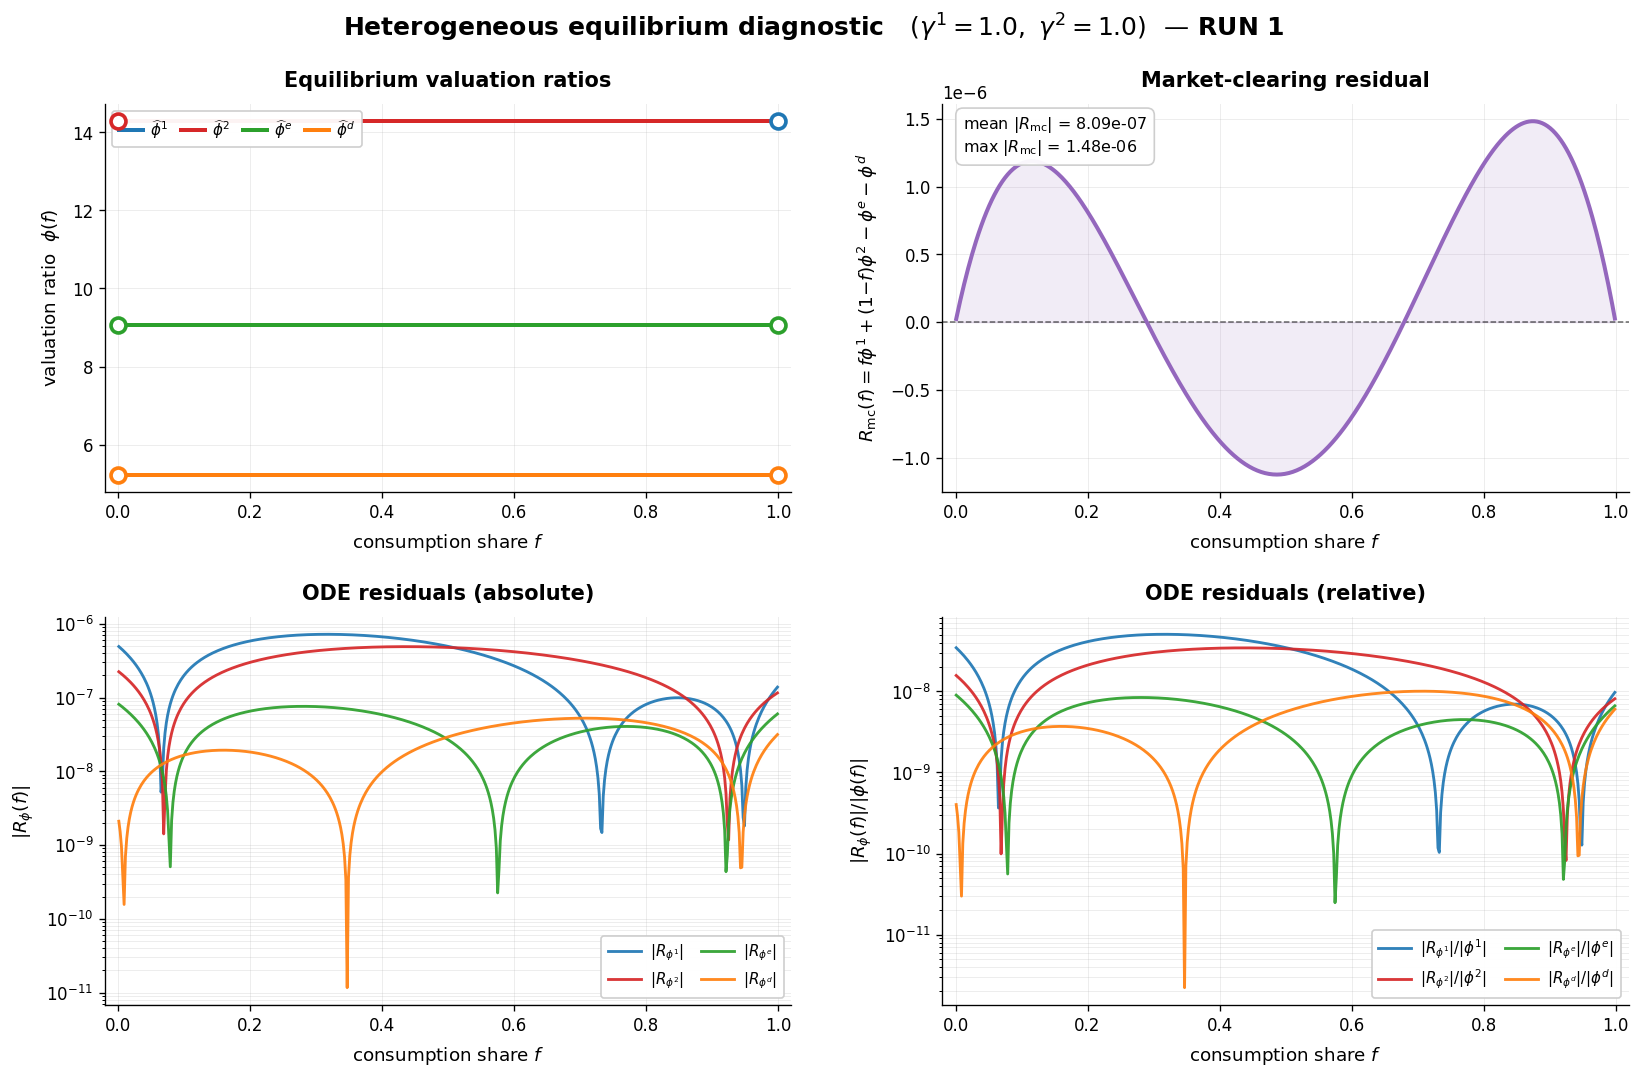

In [5]:
# =============================================================================
# Cell 4 — RUN 1: γ¹ = γ² = 1  (homogeneous log limit, validation).
#
# Both agents have log utility. The het PINN must reproduce the closed-form
# log-Merton wealth-to-consumption ratio φ_homog(1) = 1/δ ≈ 14.286 across
# the full f ∈ [0, 1] interval (Cor. 3.5). Also loads the standalone
# log-utility homog PINN for a three-way overlay on the validation plots.
# =============================================================================

print('=' * 70)
print('RUN 1: γ¹ = γ² = 1 (homog log)')
print('=' * 70)

# ---- Build the run ------------------------------------------------------
net1, compute_residuals1, constants1 = setup_run(gamma1=1.0, gamma2=1.0)
print(f'  Anchors: φ = {constants1["PHI1_INF"]:.4f}, '
      f'φᵉ = {constants1["PHIE_L"]:.4f}, '
      f'φᵈ = {constants1["PHID_L"]:.4f}')
print(f'  β_homog(1) = {constants1["b1_homog"]:.4f}')


# ---- Train --------------------------------------------------------------
history1, final_loss1 = train_run(net1, compute_residuals1,
                                  n_adam=2000, n_lbfgs=50)


# ---- Optional overlay: standalone log-utility homog PINN ---------------
phi_homog_log = load_homog_pinn_and_extract_phi('value_net_phase2_LOG.pt',
                                                 gamma=1.0)


# ---- Validate + plot ----------------------------------------------------
validate_run(net1, compute_residuals1, constants1,
             title_suffix=' — RUN 1',
             save_prefix='run1_homog_log',
             homog_phi_pinn=phi_homog_log)

---
## Cell 5 — RUN 2: $\gamma^1 = \gamma^2 = 2$ (homogeneous CRRA limit)

Validation run. Both agents have CRRA $\gamma = 2$, so the het PINN must
reproduce the closed-form CRRA wealth-to-consumption ratio
$\phi_{\mathrm{homog}}(2) \approx 11.488$ across all of $f \in [0, 1]$
(Cor. 3.3). Builds via `setup_run(2.0, 2.0)`, trains 2,000 Adam epochs + 50
L-BFGS outer iters, then validates and plots to
`run2_homog_crra.{png,pdf}`.

If `value_net_phase2_CRRA.pt` exists, the standalone CRRA homog PINN is
loaded and its extracted $\phi$ is passed to `validate_run` for a three-way
overlay. Otherwise the overlay is skipped.


RUN 2: γ¹ = γ² = 2 (homog CRRA)
  Anchors: φ = 11.4878, φᵉ = 7.4391, φᵈ = 4.0487
  β_homog(2) = 0.6476
  Adam: 2000 ep, lr=0.0001, N_coll=4000, w(agent, asset, mc) = (1.0, 1.0, 0.5)
    ep     1  loss = 1.4954e-11  L1² = 3.91e-13  L2² = 3.37e-15  Le² = 3.22e-15  Ld² = 4.88e-15  mc² = 2.91e-11
    ep   200  loss = 5.0270e-13  L1² = 1.24e-13  L2² = 6.01e-14  Le² = 1.36e-15  Ld² = 8.47e-16  mc² = 6.32e-13
    ep   400  loss = 5.0509e-13  L1² = 1.27e-13  L2² = 6.25e-14  Le² = 1.17e-15  Ld² = 9.29e-16  mc² = 6.27e-13
    ep   600  loss = 4.9614e-13  L1² = 1.21e-13  L2² = 6.06e-14  Le² = 1.11e-15  Ld² = 9.59e-16  mc² = 6.25e-13
    ep   800  loss = 4.8264e-13  L1² = 1.19e-13  L2² = 6.09e-14  Le² = 1.13e-15  Ld² = 9.88e-16  mc² = 6.02e-13
    ep  1000  loss = 4.9155e-13  L1² = 1.15e-13  L2² = 5.95e-14  Le² = 1.06e-15  Ld² = 9.56e-16  mc² = 6.31e-13
    ep  1200  loss = 4.7880e-13  L1² = 1.18e-13  L2² = 5.64e-14  Le² = 1.13e-15  Ld² = 9.74e-16  mc² = 6.05e-13
    ep  1400  loss = 4.7837e-13  L

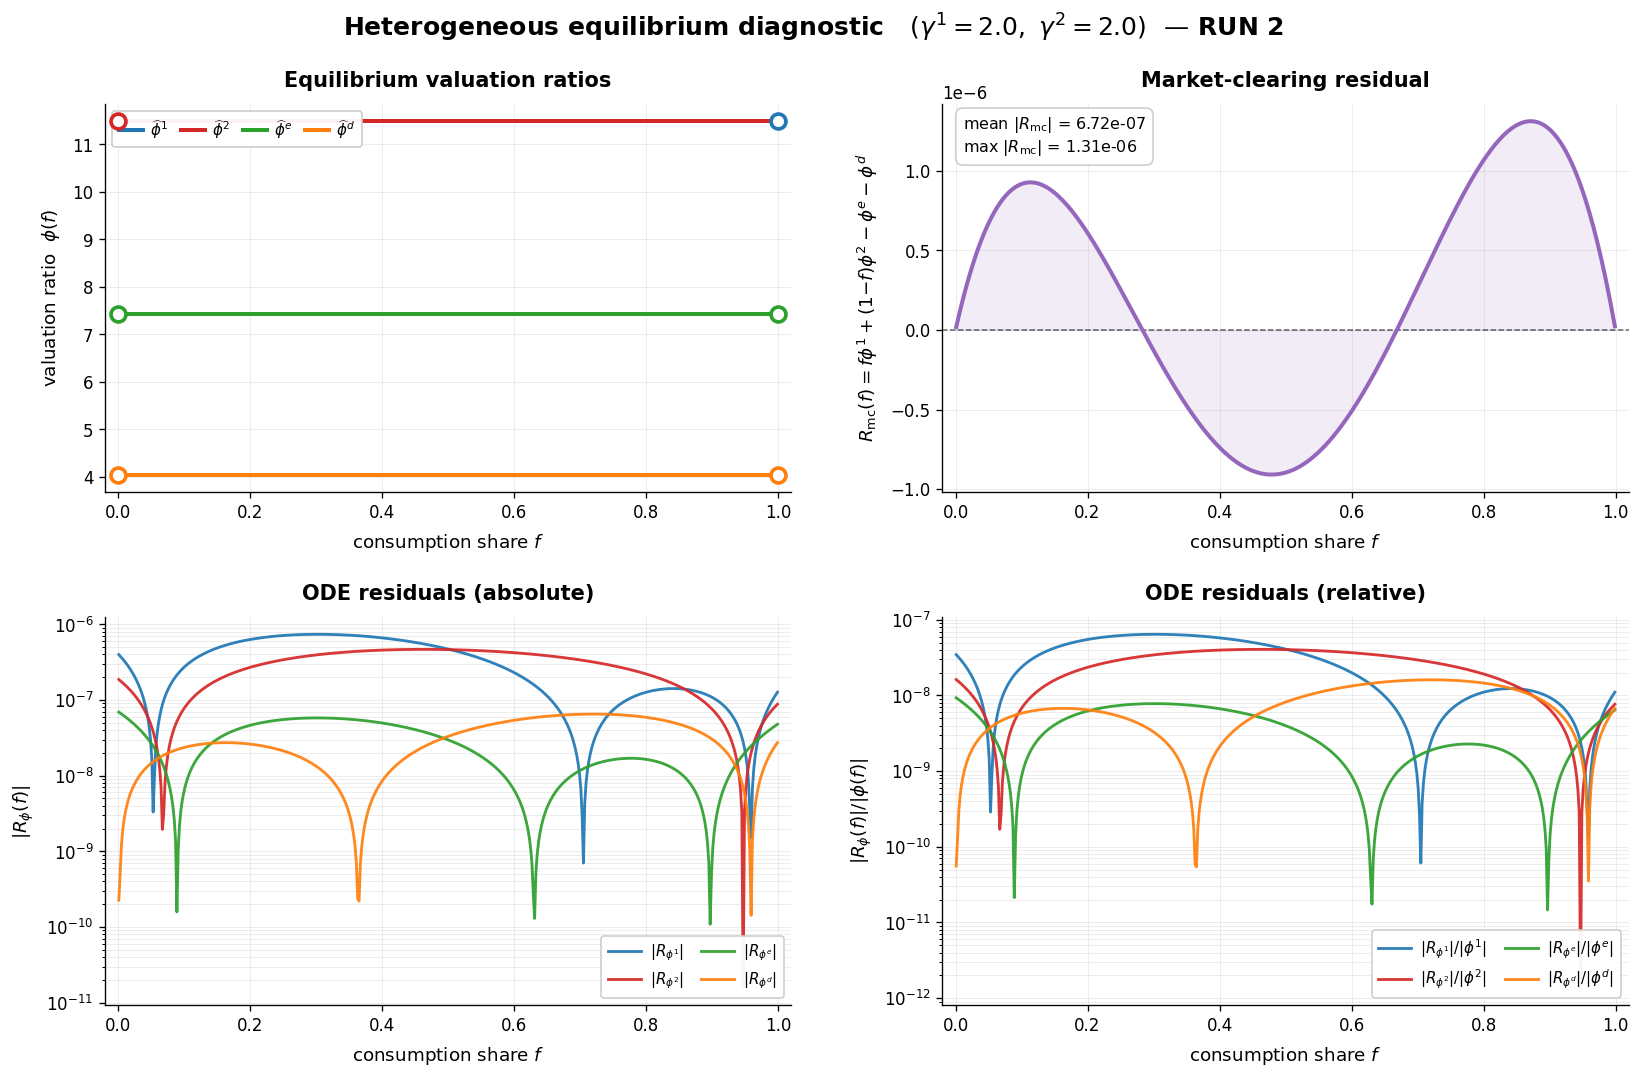

In [6]:
# =============================================================================
# Cell 5 — RUN 2: γ¹ = γ² = 2  (homogeneous CRRA limit, validation).
#
# Both agents have CRRA γ = 2. The het PINN must reproduce the closed-form
# CRRA wealth-to-consumption ratio φ_homog(2) ≈ 11.488 across the full
# f ∈ [0, 1] interval (Cor. 3.3). Loads the standalone CRRA homog PINN for
# a three-way overlay on the validation plots.
# =============================================================================

print('=' * 70)
print('RUN 2: γ¹ = γ² = 2 (homog CRRA)')
print('=' * 70)

# ---- Build the run ------------------------------------------------------
net2, compute_residuals2, constants2 = setup_run(gamma1=2.0, gamma2=2.0)
print(f'  Anchors: φ = {constants2["PHI1_INF"]:.4f}, '
      f'φᵉ = {constants2["PHIE_L"]:.4f}, '
      f'φᵈ = {constants2["PHID_L"]:.4f}')
print(f'  β_homog(2) = {constants2["b1_homog"]:.4f}')


# ---- Train --------------------------------------------------------------
history2, final_loss2 = train_run(net2, compute_residuals2,
                                  n_adam=2000, n_lbfgs=50)


# ---- Optional overlay: standalone CRRA homog PINN ----------------------
phi_homog_crra = load_homog_pinn_and_extract_phi('value_net_phase2_CRRA.pt',
                                                  gamma=2.0)


# ---- Validate + plot ----------------------------------------------------
validate_run(net2, compute_residuals2, constants2,
             title_suffix=' — RUN 2',
             save_prefix='run2_homog_crra',
             homog_phi_pinn=phi_homog_crra)


---
## Cell 6 — RUN 3: $\gamma^1 = 1,\, \gamma^2 = 2$ (truly heterogeneous, production)

The production run. Agent 1 has log utility, agent 2 has CRRA $\gamma = 2$
— no closed-form benchmark exists in the interior $f \in (0, 1)$. The two
endpoints anchor to the respective homogeneous limits (Cor. 3.5 at $f = 1$,
Cor. 3.3 at $f = 0$) and the network learns the interior interpolation.

Builds via `setup_run(1.0, 2.0)`, trains with a heavier budget than the
homog validations (3,000 Adam epochs + 100 L-BFGS outer iters), then
validates and plots to `run3_het_log_crra.{png,pdf}`. No standalone-homog
overlay because the het regime has no single-$\gamma$ reference to load.


RUN 3: γ¹ = 1, γ² = 2 (true heterogeneous, production)
  Anchors: φ¹(1) = 14.2857,  φ²(0) = 11.4878
           φᵉ(0) = 7.4391,  φᵉ(1) = 9.0525
           φᵈ(0) = 4.0487,  φᵈ(1) = 5.2332
  β_homog(γ¹ = 1) = 0.6337,  β_homog(γ² = 2) = 0.6476
  Adam: 3000 ep, lr=0.0001, N_coll=4000, w(agent, asset, mc) = (1.0, 1.0, 0.5)
    ep     1  loss = 3.8646e-03  L1² = 3.17e-13  L2² = 1.20e-03  Le² = 1.91e-05  Ld² = 8.52e-06  mc² = 5.27e-03
    ep   200  loss = 1.0237e-03  L1² = 1.06e-06  L2² = 9.74e-04  Le² = 2.14e-05  Ld² = 8.13e-06  mc² = 3.93e-05
    ep   400  loss = 9.6179e-04  L1² = 2.77e-07  L2² = 9.13e-04  Le² = 1.64e-05  Ld² = 6.94e-06  mc² = 5.04e-05
    ep   600  loss = 9.2009e-04  L1² = 3.07e-07  L2² = 8.65e-04  Le² = 1.40e-05  Ld² = 6.20e-06  mc² = 6.86e-05
    ep   800  loss = 9.4569e-04  L1² = 5.69e-07  L2² = 8.87e-04  Le² = 1.24e-05  Ld² = 5.55e-06  mc² = 7.96e-05
    ep  1000  loss = 9.1588e-04  L1² = 1.65e-06  L2² = 8.65e-04  Le² = 1.05e-05  Ld² = 5.03e-06  mc² = 6.65e-05
    ep  1

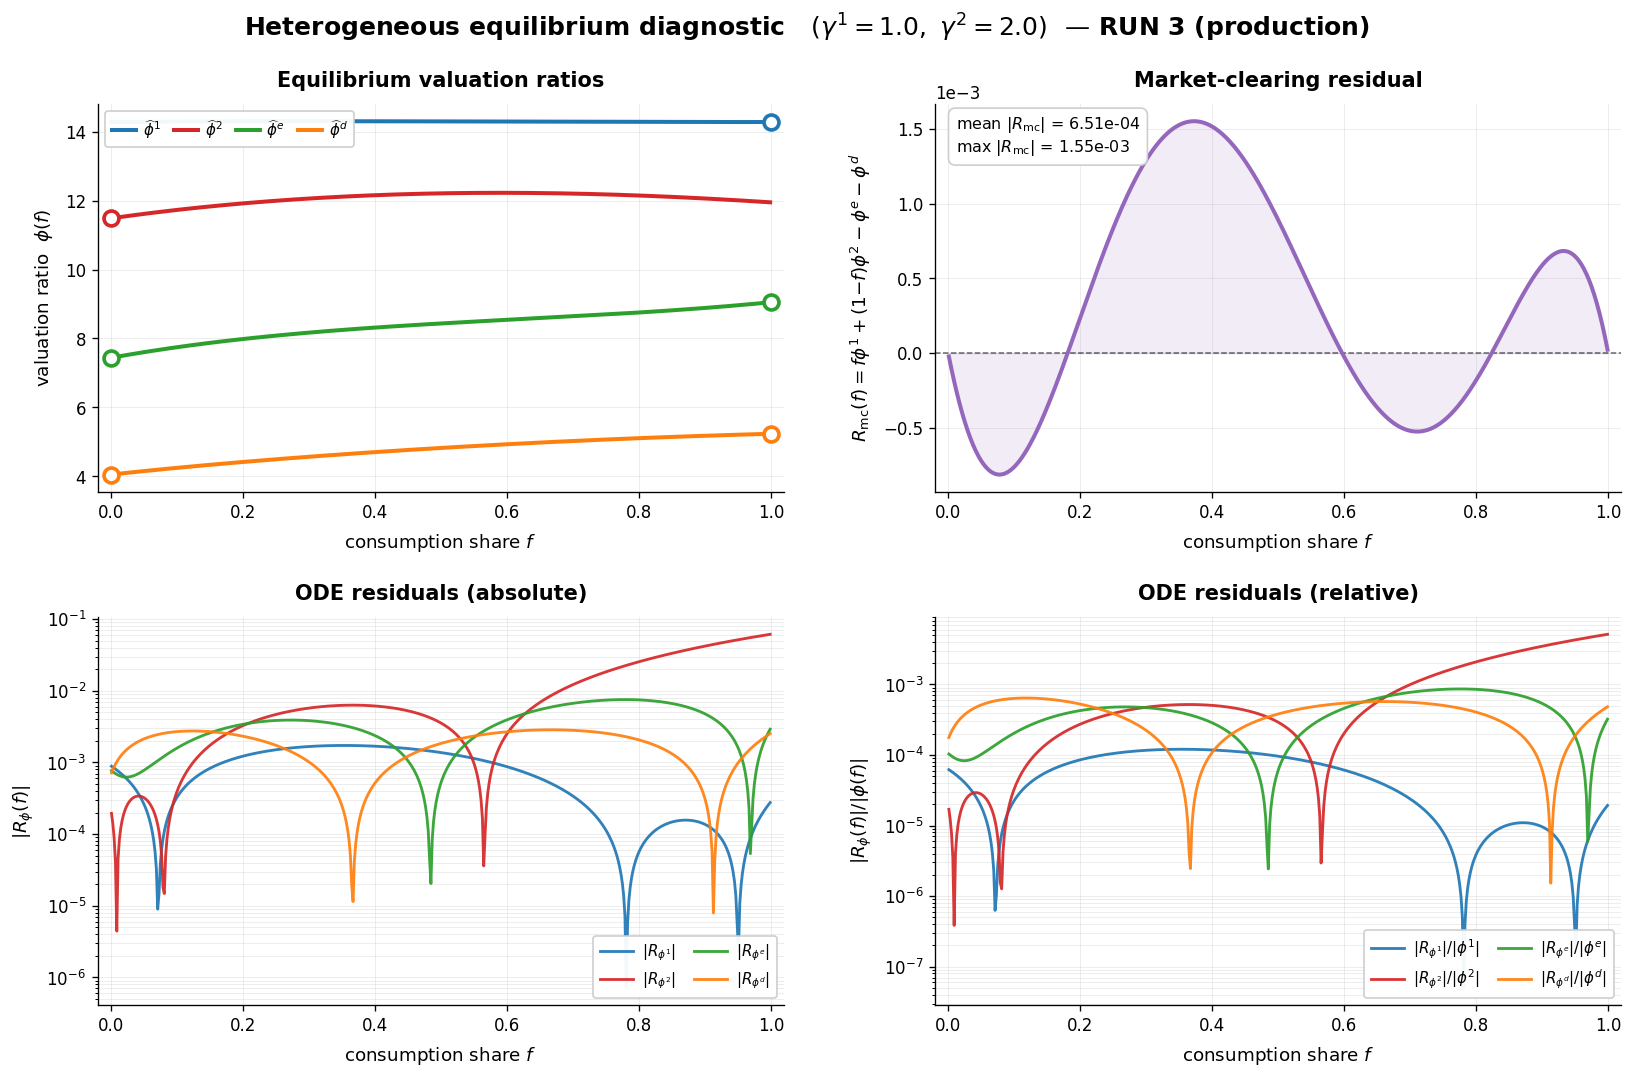

In [7]:
# =============================================================================
# Cell 6 — RUN 3: γ¹ = 1, γ² = 2  (truly heterogeneous, production).
#
# Agent 1 has log utility, agent 2 has CRRA γ = 2 — no homogeneous
# closed-form benchmark in the interior. The two endpoints are anchored to
# the respective homog limits (Cor. 3.5 at f = 1, Cor. 3.3 at f = 0), and
# the network learns the interior interpolation. Heavier training budget
# than the homog validations (3,000 Adam epochs, 100 L-BFGS outer iters).
# No standalone-homog overlay because the het regime has no single-γ
# reference to load.
# =============================================================================

print('=' * 70)
print('RUN 3: γ¹ = 1, γ² = 2 (true heterogeneous, production)')
print('=' * 70)

# ---- Build the run ------------------------------------------------------
net3, compute_residuals3, constants3 = setup_run(gamma1=1.0, gamma2=2.0)
print(f'  Anchors: φ¹(1) = {constants3["PHI1_INF"]:.4f},  φ²(0) = {constants3["PHI2_INF"]:.4f}')
print(f'           φᵉ(0) = {constants3["PHIE_L"]:.4f},  φᵉ(1) = {constants3["PHIE_R"]:.4f}')
print(f'           φᵈ(0) = {constants3["PHID_L"]:.4f},  φᵈ(1) = {constants3["PHID_R"]:.4f}')
print(f'  β_homog(γ¹ = 1) = {constants3["b1_homog"]:.4f},  '
      f'β_homog(γ² = 2) = {constants3["b2_homog"]:.4f}')


# ---- Train (heavier budget than the homog validations) -----------------
history3, final_loss3 = train_run(net3, compute_residuals3,
                                  n_adam=3000, n_lbfgs=100)


# ---- Validate + plot ----------------------------------------------------
validate_run(net3, compute_residuals3, constants3,
             title_suffix=' — RUN 3 (production)',
             save_prefix='run3_het_log_crra')


---
## Cell 7 — Cross-run summary and production checkpoint

Prints the three final losses side-by-side and saves the Run 3 (production
het) network to `net_het_structBaseline_g1_g2.pt` for downstream analysis
and figure-appendix reloads.


In [8]:
# =============================================================================
# Cell 7 — Cross-run summary and production checkpoint.
#
# Prints the three final losses side-by-side and saves the production (Run 3)
# network so downstream analysis cells / the thesis figure appendix can
# reload it without re-running the training.
# =============================================================================

print('=' * 70)
print('SUMMARY OF ALL RUNS')
print('=' * 70)
print(f'  Run 1 (γ¹ = γ² = 1, homog log) :  final loss = {final_loss1:.6e}')
print(f'  Run 2 (γ¹ = γ² = 2, homog CRRA):  final loss = {final_loss2:.6e}')
print(f'  Run 3 (γ¹ = 1, γ² = 2, het)    :  final loss = {final_loss3:.6e}')


# ---- Save the production (Run 3) network --------------------------------
torch.save(net3.state_dict(), 'net_het_structBaseline_g1_g2.pt')
print(f'\nSaved production network → net_het_structBaseline_g1_g2.pt')


SUMMARY OF ALL RUNS
  Run 1 (γ¹ = γ² = 1, homog log) :  final loss = 7.478659e-13
  Run 2 (γ¹ = γ² = 2, homog CRRA):  final loss = 6.061352e-13
  Run 3 (γ¹ = 1, γ² = 2, het)    :  final loss = 1.965896e-03

Saved production network → net_het_structBaseline_g1_g2.pt


---
## Cell 8 — Comparison run: Garleanu–Panageas (2015) calibration

Reproduces the canonical Garleanu–Panageas (2015) two-type heterogeneous
calibration ($\gamma^1 = 1.5,\, \gamma^2 = 10,\, \alpha^1_{\text{pop}} = 0.01$)
to compare the het PINN against their published results. Overwrites the
global primitives $\rho \to 10^{-3}$ and $\sigma_Y \to 1.77\%$, and the
population fractions to $(0.01,\, 0.99)$, then runs `setup_run`,
`train_run`, and `validate_run` with the same heavier training budget as
Run 3 (3,000 Adam epochs + 100 L-BFGS outer iters).

The reused variable names (`net3`, `constants3`, `final_loss3`, …) and the
`'RUN 3'` banner shadow the original Run 3 state — see flags below.


RUN 3: γ¹ = 1.5, γ² = 10.0 (true heterogeneous, production)
  Anchors: φ¹(1) = 28.3454,  φ²(0) = 4.0967
           φᵉ(0) = 2.7949,  φᵉ(1) = 15.8830
           φᵈ(0) = 1.3018,  φᵈ(1) = 12.4624
  β_homog(γ¹ = 1.5) = 0.5603,  β_homog(γ² = 10.0) = 0.6822
  Adam: 3000 ep, lr=0.0001, N_coll=4000, w(agent, asset, mc) = (1.0, 1.0, 0.5)
    ep     1  loss = 4.7142e-01  L1² = 1.66e-02  L2² = 1.30e-02  Le² = 7.72e-03  Ld² = 7.40e-03  mc² = 8.53e-01
    ep   200  loss = 7.7620e-02  L1² = 2.16e-02  L2² = 1.88e-02  Le² = 7.86e-03  Ld² = 5.44e-03  mc² = 4.80e-02
    ep   400  loss = 6.7866e-02  L1² = 2.07e-02  L2² = 2.35e-02  Le² = 8.73e-03  Ld² = 5.01e-03  mc² = 2.00e-02
    ep   600  loss = 6.3770e-02  L1² = 1.98e-02  L2² = 2.35e-02  Le² = 8.69e-03  Ld² = 4.22e-03  mc² = 1.52e-02
    ep   800  loss = 5.9108e-02  L1² = 1.85e-02  L2² = 2.21e-02  Le² = 8.28e-03  Ld² = 3.50e-03  mc² = 1.36e-02
    ep  1000  loss = 5.6409e-02  L1² = 1.81e-02  L2² = 2.10e-02  Le² = 8.20e-03  Ld² = 2.94e-03  mc² = 1.23e-0

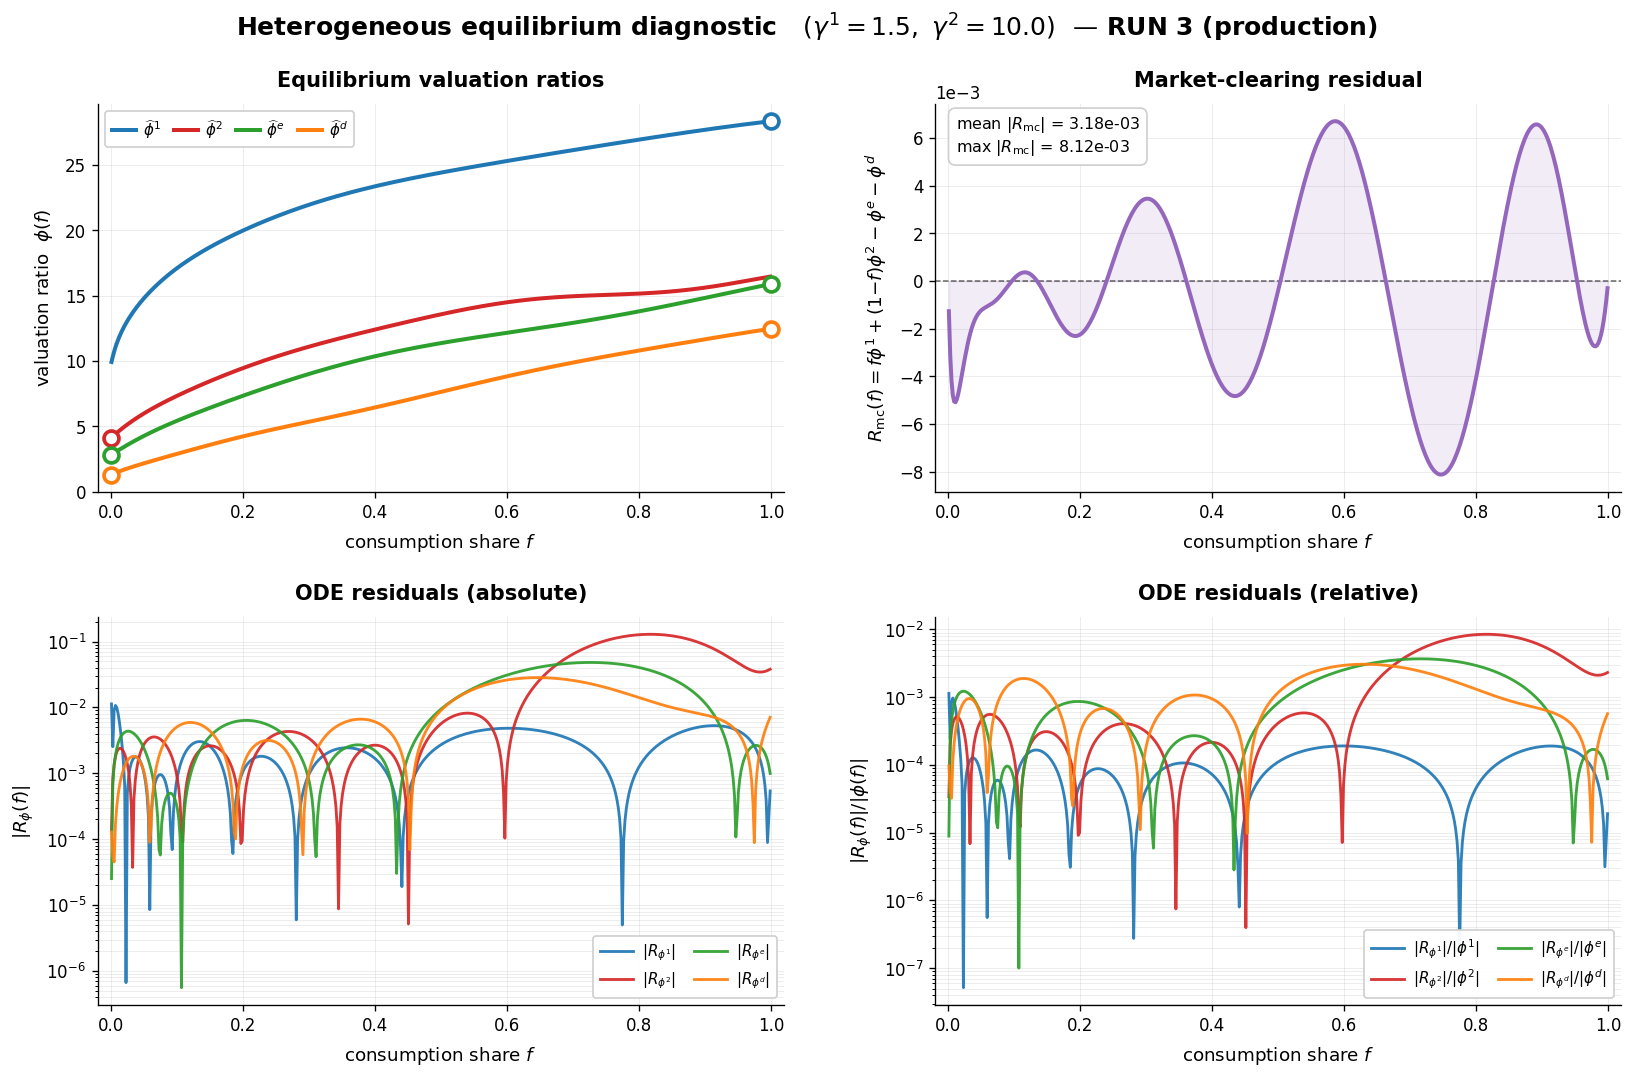

In [9]:
# =============================================================================
# Cell 8 — Comparison run: Garleanu–Panageas (2015) calibration.
#
#   γ¹ = 1.5, γ² = 10.0, with the GP15 two-type calibration:
#     • ρ = 0.001 (vs. 0.05 baseline)
#     • σ_Y = 0.0177 (vs. 0.10 baseline)
#     • α¹_pop = 0.01, α²_pop = 0.99
#
# Reproduces the Garleanu–Panageas (2015) two-type heterogeneous setting so
# we can overlay our PINN solution on their published results.
#
# WARNING — global state mutation: this cell rebinds the module-level
# primitives (ρ, ν, μ_Y, σ_Y, ω) and population fractions (ALPHA_POP1/2) to
# the GP15 values. All subsequent cells that read these globals will see the
# GP15 values, not the original calibration. It also rebinds net3 /
# compute_residuals3 / constants3 / history3 / final_loss3, overwriting the
# original Run 3 in-memory state. The on-disk checkpoint
# `net_het_structBaseline_g1_g2.pt` (saved in Cell 7) is preserved.
# =============================================================================

# ---- GP15 calibration (globals overwritten) -----------------------------
rho   = 0.001              # subjective discount rate (GP15: 0.001 vs. baseline 0.05)
nu    = 0.02               # death rate (unchanged)
mu_Y  = 0.02               # mean Y growth (unchanged)
sig_Y = 0.0177             # Y volatility (GP15: 1.77% vs. baseline 10%)
omega = 0.7                # wage share (unchanged)
sig_S = sig_Y              # σ^S = σ_Y (single-shock economy)

ALPHA_POP1 = 0.01          # type-A (γ^1 = 1.5) population fraction
ALPHA_POP2 = 0.99          # type-B (γ^2 = 10)  population fraction


# ---- Banner -------------------------------------------------------------
print('=' * 70)
print('RUN 3: γ¹ = 1.5, γ² = 10.0 (true heterogeneous, production)')
print('=' * 70)


# ---- Build the run ------------------------------------------------------
net3, compute_residuals3, constants3 = setup_run(gamma1=1.5, gamma2=10.0)
print(f'  Anchors: φ¹(1) = {constants3["PHI1_INF"]:.4f},  φ²(0) = {constants3["PHI2_INF"]:.4f}')
print(f'           φᵉ(0) = {constants3["PHIE_L"]:.4f},  φᵉ(1) = {constants3["PHIE_R"]:.4f}')
print(f'           φᵈ(0) = {constants3["PHID_L"]:.4f},  φᵈ(1) = {constants3["PHID_R"]:.4f}')
print(f'  β_homog(γ¹ = 1.5) = {constants3["b1_homog"]:.4f},  '
      f'β_homog(γ² = 10.0) = {constants3["b2_homog"]:.4f}')


# ---- Train + validate ---------------------------------------------------
history3, final_loss3 = train_run(net3, compute_residuals3,
                                  n_adam=3000, n_lbfgs=100)

validate_run(net3, compute_residuals3, constants3,
             title_suffix=' — RUN 3 (production)',
             save_prefix='run3_het_log_crra')


## Cell 9 — Garleanu–Panageas (2015) Figure 1 reproduction

Run immediately after Cell 8 (GP15 calibration). Reuses `net3` and
`constants3` plus the GP15-rebound primitives.

**Five steps:**

1. Saves the trained net under `net_het_GP2015_calibration.pt`.
2. Evaluates the four $\widehat\phi^i$ on a dense $N_F = 401$ interior grid,
   with autograd derivatives $d\widehat\phi^e/df$ and $d\widehat\phi^d/df$
   needed for return volatility.
3. Computes the equilibrium quantities — endogenous $\beta$, harmonic EIS
   $R(f)$, risk-sharing intensity $P(f)$, state volatility $\sigma_f$,
   market price of risk $\theta = R\sigma_Y$, short rate
   $r = \rho + R\mu_Y - \tfrac{1}{2}RP\sigma_Y^2 + R\nu(1-\beta)$, return
   volatility $\sigma_R = \sigma_Y + (d\log(\phi^e + \phi^d)/df)\,\sigma_f$,
   and equity premium $EP = \theta\,\sigma_R$.
4. Plots a 2 × 2 figure on $f \in [0,\, 0.30]$ matching GP15 Figure 1
   (equity premium, market price of risk, interest rate, return
   volatility). Saves to `Results_hetero/gp2015_figure1_reproduction.png`.
5. Prints the four quantities at $f \in \{0.01,\, 0.05,\, 0.10,\, 0.20,\, 0.30\}$
   for direct numerical comparison with GP15 Table 1.

Saved net_het_GP2015_calibration.pt  (283.7 KB)


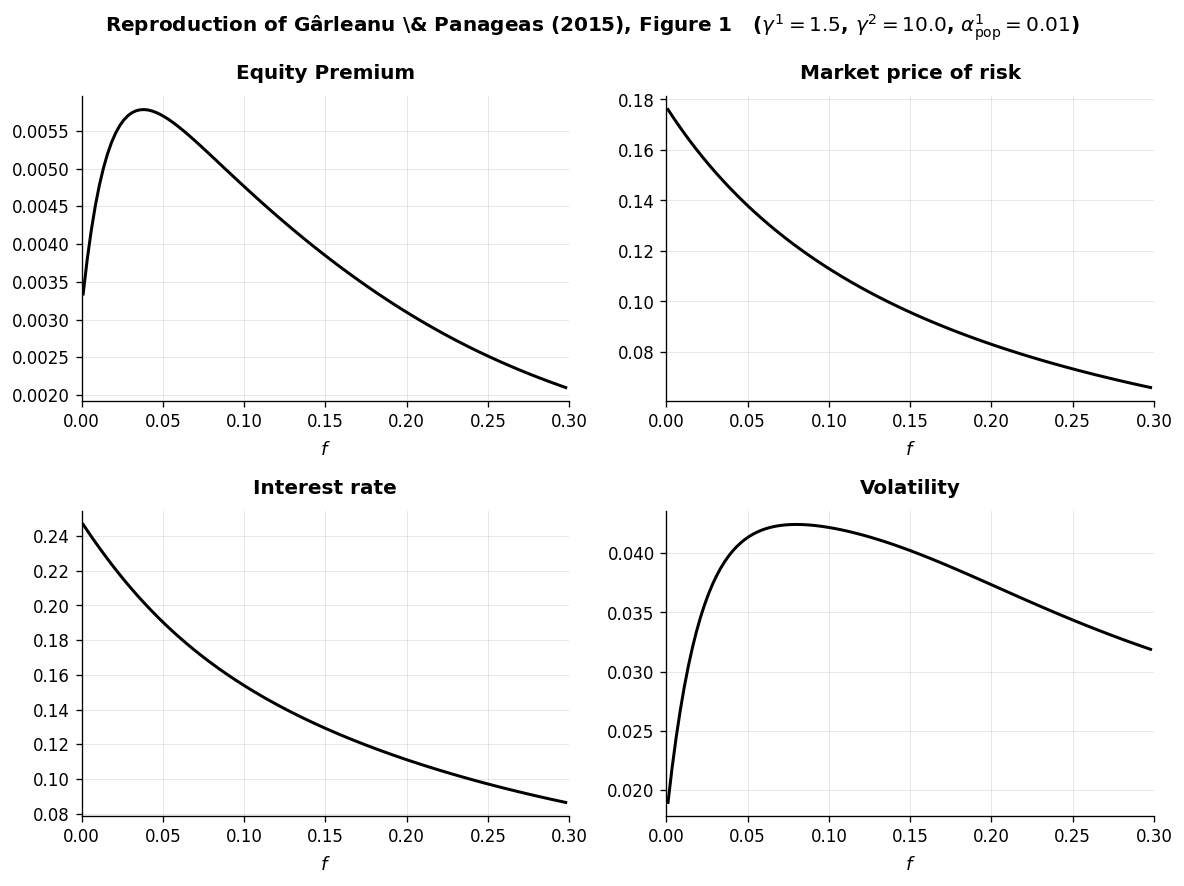


=== Values at key consumption-share levels (your trained network) ===
  f = 0.01:  EP = 0.0048   θ = 0.1666   r = 0.2332   σ_R = 0.0287
  f = 0.05:  EP = 0.0057   θ = 0.1374   r = 0.1897   σ_R = 0.0414
  f = 0.10:  EP = 0.0047   θ = 0.1127   r = 0.1534   σ_R = 0.0421
  f = 0.20:  EP = 0.0031   θ = 0.0828   r = 0.1109   σ_R = 0.0373
  f = 0.30:  EP = 0.0021   θ = 0.0655   r = 0.0860   σ_R = 0.0318


In [10]:
# =============================================================================
# Cell 9 — Garleanu–Panageas (2015) Figure 1 reproduction.
#
# Run this IMMEDIATELY after Cell 8 (the GP15 calibration run with γ¹ = 1.5,
# γ² = 10): it reuses `net3`, `constants3`, and the GP15-rebound module-level
# primitives (ρ, σ_Y, ω, ν, μ_Y, ALPHA_POP1/2). Saves the trained network
# under a GP-specific checkpoint name and produces a 2 × 2 figure matching
# the layout of GP15 Figure 1 (equity premium, market price of risk,
# interest rate, return volatility), all as functions of f ∈ [0, 0.30].
# =============================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

os.makedirs('Results_hetero', exist_ok=True)


# ---- 1. Save the trained network under a GP-specific filename ----------
GP_CKPT = 'net_het_GP2015_calibration.pt'
torch.save(net3.state_dict(), GP_CKPT)
print(f'Saved {GP_CKPT}  ({os.path.getsize(GP_CKPT) / 1e3:.1f} KB)')


# ---- 2. Evaluate net3 on a dense interior grid (with autograd for σ_R) -
N_F = 401
f_t = (F_EPS + (1 - 2 * F_EPS) *
       torch.linspace(0, 1, N_F, device=device)).requires_grad_(True)
phi1_t, phi2_t, phie_t, phid_t = net3(f_t)

# Autograd derivatives of φ^e and φ^d are needed only for the return volatility σ_R.
g_one    = torch.ones_like(phi1_t)
dphie_t, = torch.autograd.grad(phie_t, f_t, g_one, create_graph=False, retain_graph=True)
dphid_t, = torch.autograd.grad(phid_t, f_t, g_one, create_graph=False, retain_graph=False)

f_grid   = f_t.detach().cpu().numpy()
phi1_f   = phi1_t.detach().cpu().numpy()
phi2_f   = phi2_t.detach().cpu().numpy()
phi_e_f  = phie_t.detach().cpu().numpy()
phi_d_f  = phid_t.detach().cpu().numpy()
dphi_e_f = dphie_t.detach().cpu().numpy()
dphi_d_f = dphid_t.detach().cpu().numpy()


# ---- 3. Equilibrium quantities (GP calibration) ------------------------
gamma1, gamma2 = constants3['gamma1'], constants3['gamma2']

# Endogenous β decomposition
b1_f = ALPHA_POP1 * phi_e_f / phi1_f
b2_f = ALPHA_POP2 * phi_e_f / phi2_f
b_f  = b1_f + b2_f

# Aggregate quantities R(f), P(f), σ_f(f), market price of risk θ(f), r(f)
R_f       = 1.0 / (f_grid / gamma1 + (1 - f_grid) / gamma2)
P_num     = f_grid / gamma1 ** 2 + (1 - f_grid) / gamma2 ** 2
P_den     = (f_grid / gamma1 + (1 - f_grid) / gamma2) ** 2
P_f       = P_num / P_den + R_f
theta_f   = R_f * sig_Y                                                      # market price of risk
sig_f_arr = f_grid * (R_f / gamma1 - 1.0) * sig_Y                            # volatility of state f
r_f       = rho + R_f * mu_Y - 0.5 * R_f * P_f * sig_Y ** 2 + R_f * nu * (1.0 - b_f)

# Return volatility σ_R: σ_Y plus the f-volatility contribution through d log(φ^e + φ^d)/df
phi_tot   = phi_e_f + phi_d_f
dlog_dphi = (dphi_e_f + dphi_d_f) / phi_tot
sigma_R   = sig_Y + dlog_dphi * sig_f_arr
EP_f      = theta_f * sigma_R                                                # equity premium = θ · σ_R


# ---- 4. Reproduce the GP15 Figure 1 layout (2 × 2, f ∈ [0, 0.30]) ------
X_MAX = 0.30                                                                 # GP15's display range
mask  = f_grid <= X_MAX
f_x   = f_grid[mask]

fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

axes[0, 0].plot(f_x, EP_f[mask],    'k-', lw=1.8)
axes[0, 0].set_title('Equity Premium', fontsize=12)
axes[0, 0].set_xlabel('$f$')
axes[0, 0].grid(True, alpha=0.3); axes[0, 0].set_xlim(0, X_MAX)

axes[0, 1].plot(f_x, theta_f[mask], 'k-', lw=1.8)
axes[0, 1].set_title('Market price of risk', fontsize=12)
axes[0, 1].set_xlabel('$f$')
axes[0, 1].grid(True, alpha=0.3); axes[0, 1].set_xlim(0, X_MAX)

axes[1, 0].plot(f_x, r_f[mask],     'k-', lw=1.8)
axes[1, 0].set_title('Interest rate', fontsize=12)
axes[1, 0].set_xlabel('$f$')
axes[1, 0].grid(True, alpha=0.3); axes[1, 0].set_xlim(0, X_MAX)

axes[1, 1].plot(f_x, sigma_R[mask], 'k-', lw=1.8)
axes[1, 1].set_title('Volatility', fontsize=12)
axes[1, 1].set_xlabel('$f$')
axes[1, 1].grid(True, alpha=0.3); axes[1, 1].set_xlim(0, X_MAX)

plt.suptitle(rf'Reproduction of Gârleanu \& Panageas (2015), Figure 1   '
             rf'($\gamma^1={gamma1}$, $\gamma^2={gamma2}$, '
             rf'$\alpha^1_{{\mathrm{{pop}}}}={ALPHA_POP1}$)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Results_hetero/gp2015_figure1_reproduction.png',
            dpi=200, bbox_inches='tight')
plt.show()


# ---- 5. Numerical readout at key consumption-share levels --------------
def value_at(arr, f_target):
    """Return arr at the grid point closest to f_target."""
    idx = np.argmin(np.abs(f_grid - f_target))
    return arr[idx]

print()
print('=== Values at key consumption-share levels (your trained network) ===')
for f_q in [0.01, 0.05, 0.10, 0.20, 0.30]:
    print(f'  f = {f_q:.2f}:  '
          f'EP = {value_at(EP_f, f_q):.4f}   '
          f'θ = {value_at(theta_f, f_q):.4f}   '
          f'r = {value_at(r_f, f_q):.4f}   '
          f'σ_R = {value_at(sigma_R, f_q):.4f}')

## Cell 10 — Interest-rate decomposition

Run after Cell 9. Splits the equilibrium short rate

$$
r(f) \;=\; \underbrace{\rho}_{\text{pure discount}}
        \;+\; \underbrace{R(f)\,\mu_Y}_{\text{income / growth}}
        \;-\; \underbrace{\tfrac{1}{2} R(f) P(f) \sigma_Y^2}_{\text{precautionary}}
        \;+\; \underbrace{R(f)\,\nu\,(1-\beta(f))}_{\text{mortality / newborn risk}}
$$

into its four additive contributions and plots them in two views: a
separate-line panel (each term as its own curve) and a stacked-area panel
(showing how the four terms aggregate into total $r(f)$). Display window
$f \in [0,\, 0.30]$ matches GP15 Figure 1. Saved to
`Results_hetero/interest_rate_decomposition.png`.

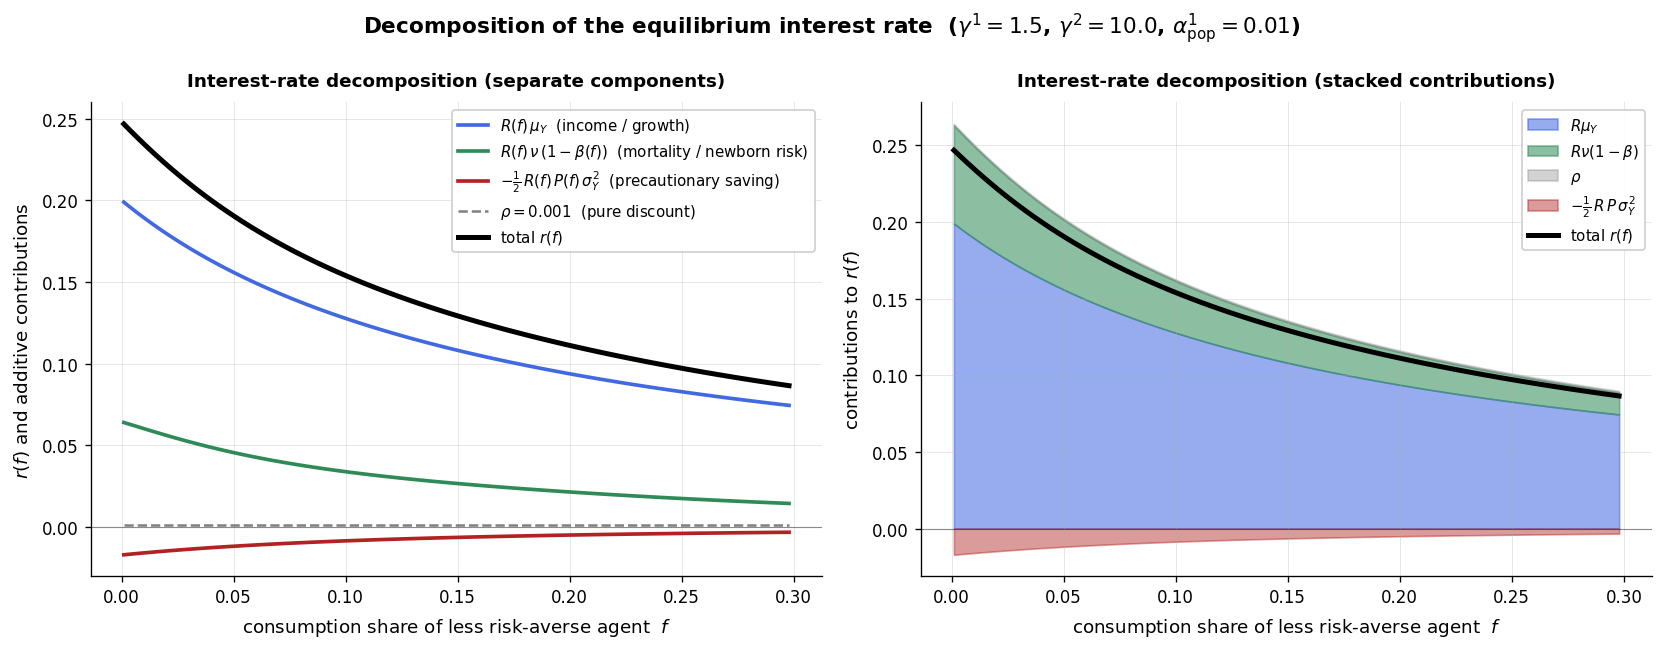

In [11]:
# =============================================================================
# Cell 10 — Interest-rate decomposition: r(f) into its four additive parts.
#
# Run after Cell 9 (which sets up f_grid, phi_e_f, phi1_f, phi2_f, gamma1,
# gamma2, ALPHA_POP1, ALPHA_POP2, and the GP15-rebound primitives).
#
# Formula (Prop. 3.3):
#   r(f) = ρ                                  (pure discount)
#        + R(f) · μ_Y                         (income / growth)
#        − ½ R(f) · P(f) · σ_Y²               (precautionary saving)
#        + R(f) · ν · (1 − β(f))              (mortality / newborn-risk).
#
# Two views of the same decomposition: separate-line plot (left panel) and
# stacked-area plot (right panel), restricted to the GP display window
# f ∈ [0, 0.30].
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('Results_hetero', exist_ok=True)


# ---- 1. Recompute R(f), P(f), β(f) from the trained network ------------
R_arr = 1.0 / (f_grid / gamma1 + (1 - f_grid) / gamma2)
P_num = f_grid / gamma1 ** 2 + (1 - f_grid) / gamma2 ** 2
P_den = (f_grid / gamma1 + (1 - f_grid) / gamma2) ** 2
P_arr = P_num / P_den + R_arr

b1 = ALPHA_POP1 * phi_e_f / phi1_f
b2 = ALPHA_POP2 * phi_e_f / phi2_f
b  = b1 + b2


# ---- 2. Four additive contributions to r(f) ----------------------------
term_discount      = rho * np.ones_like(f_grid)                              # ρ
term_income        = R_arr * mu_Y                                            # R(f) · μ_Y
term_precautionary = -0.5 * R_arr * P_arr * sig_Y ** 2                       # −½ R(f) · P(f) · σ_Y²
term_mortality     = R_arr * nu * (1.0 - b)                                  # R(f) · ν · (1 − β(f))
total_r            = (term_discount + term_income
                      + term_precautionary + term_mortality)


# ---- 3. Restrict to the GP display window f ∈ [0, 0.30] ----------------
mask = f_grid <= 0.30
f_x  = f_grid[mask]


# ---- 4. Two-panel plot --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A — separate-line decomposition
ax = axes[0]
ax.plot(f_x, term_income[mask],        lw=2.2, color='royalblue',
        label=r'$R(f)\,\mu_Y$  (income / growth)')
ax.plot(f_x, term_mortality[mask],     lw=2.2, color='seagreen',
        label=r'$R(f)\,\nu\,(1-\beta(f))$  (mortality / newborn risk)')
ax.plot(f_x, term_precautionary[mask], lw=2.2, color='firebrick',
        label=r'$-\frac{1}{2}\,R(f)\,P(f)\,\sigma_Y^2$  (precautionary saving)')
ax.plot(f_x, term_discount[mask],      lw=1.5, color='gray', ls='--',
        label=fr'$\rho = {rho}$  (pure discount)')
ax.plot(f_x, total_r[mask],            lw=3.0, color='black',
        label=r'total $r(f)$', zorder=10)
ax.axhline(0, color='k', lw=0.7, alpha=0.4)
ax.set_xlabel(r'consumption share of less risk-averse agent  $f$')
ax.set_ylabel(r'$r(f)$ and additive contributions')
ax.set_title('Interest-rate decomposition (separate components)',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, framealpha=0.95)

# Panel B — stacked-area view
ax = axes[1]
ax.fill_between(f_x, 0, term_income[mask],
                color='royalblue', alpha=0.55, label=r'$R\mu_Y$')
ax.fill_between(f_x, term_income[mask],
                term_income[mask] + term_mortality[mask],
                color='seagreen', alpha=0.55, label=r'$R\nu(1-\beta)$')
ax.fill_between(f_x, term_income[mask] + term_mortality[mask],
                term_income[mask] + term_mortality[mask] + term_discount[mask],
                color='gray', alpha=0.35, label=r'$\rho$')
ax.fill_between(f_x, 0, term_precautionary[mask],
                color='firebrick', alpha=0.45,
                label=r'$-\frac{1}{2}\,R\,P\,\sigma_Y^2$')
ax.plot(f_x, total_r[mask], lw=3.0, color='black',
        label=r'total $r(f)$', zorder=10)
ax.axhline(0, color='k', lw=0.7, alpha=0.4)
ax.set_xlabel(r'consumption share of less risk-averse agent  $f$')
ax.set_ylabel(r'contributions to $r(f)$')
ax.set_title('Interest-rate decomposition (stacked contributions)',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, framealpha=0.95)

plt.suptitle('Decomposition of the equilibrium interest rate  '
             rf'($\gamma^1={gamma1}$, $\gamma^2={gamma2}$, '
             rf'$\alpha^1_{{\mathrm{{pop}}}}={ALPHA_POP1}$)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Results_hetero/interest_rate_decomposition.png',
            dpi=200, bbox_inches='tight')
plt.show()

Companion to Cell 10: same four-term decomposition and same two-panel
layout (separate-line on the left, stacked-area on the right), but plotted
over $f \in [0, 1]$ instead of the GP15 display window $[0, 0.30]$. Useful
for seeing how each contribution behaves as the economy transitions from
all type-2 ($f = 0$) to all type-1 ($f = 1$).

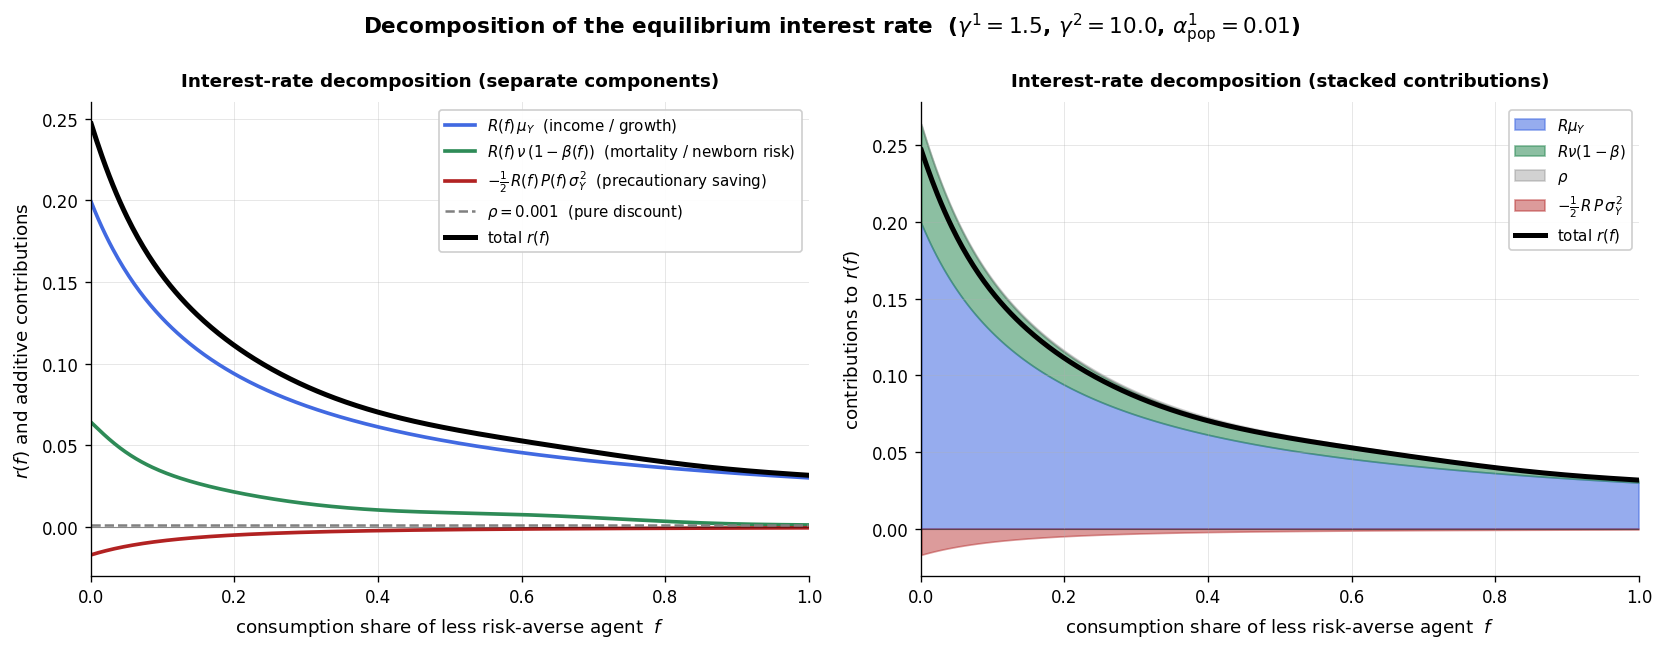

In [12]:
# =============================================================================
# Cell 11 — Interest-rate decomposition over the full state space f ∈ [0, 1].
#
# Companion to Cell 10. Same four-term decomposition, same two-panel layout
# (separate-line + stacked-area), but plotted over the entire population
# share interval [0, 1] instead of the GP15 display window [0, 0.30]. Useful
# for seeing how each contribution behaves as the economy transitions from
# all type-2 (f = 0) to all type-1 (f = 1).
#
# Formula (Prop. 3.3):
#   r(f) = ρ                                  (pure discount)
#        + R(f) · μ_Y                         (income / growth)
#        − ½ R(f) · P(f) · σ_Y²               (precautionary saving)
#        + R(f) · ν · (1 − β(f))              (mortality / newborn-risk).
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('Results_hetero', exist_ok=True)


# ---- 1. Recompute R(f), P(f), β(f) from the trained network ------------
R_arr = 1.0 / (f_grid / gamma1 + (1 - f_grid) / gamma2)
P_num = f_grid / gamma1 ** 2 + (1 - f_grid) / gamma2 ** 2
P_den = (f_grid / gamma1 + (1 - f_grid) / gamma2) ** 2
P_arr = P_num / P_den + R_arr

b1 = ALPHA_POP1 * phi_e_f / phi1_f
b2 = ALPHA_POP2 * phi_e_f / phi2_f
b  = b1 + b2


# ---- 2. Four additive contributions to r(f) ----------------------------
term_discount      = rho * np.ones_like(f_grid)                              # ρ
term_income        = R_arr * mu_Y                                            # R(f) · μ_Y
term_precautionary = -0.5 * R_arr * P_arr * sig_Y ** 2                       # −½ R(f) · P(f) · σ_Y²
term_mortality     = R_arr * nu * (1.0 - b)                                  # R(f) · ν · (1 − β(f))
total_r            = (term_discount + term_income
                      + term_precautionary + term_mortality)


# ---- 3. Two-panel plot over the full state space f ∈ [0, 1] ------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A — separate-line decomposition
ax = axes[0]
ax.plot(f_grid, term_income,        lw=2.2, color='royalblue',
        label=r'$R(f)\,\mu_Y$  (income / growth)')
ax.plot(f_grid, term_mortality,     lw=2.2, color='seagreen',
        label=r'$R(f)\,\nu\,(1-\beta(f))$  (mortality / newborn risk)')
ax.plot(f_grid, term_precautionary, lw=2.2, color='firebrick',
        label=r'$-\frac{1}{2}\,R(f)\,P(f)\,\sigma_Y^2$  (precautionary saving)')
ax.plot(f_grid, term_discount,      lw=1.5, color='gray', ls='--',
        label=fr'$\rho = {rho}$  (pure discount)')
ax.plot(f_grid, total_r,            lw=3.0, color='black',
        label=r'total $r(f)$', zorder=10)
ax.axhline(0, color='k', lw=0.7, alpha=0.4)
ax.set_xlabel(r'consumption share of less risk-averse agent  $f$')
ax.set_ylabel(r'$r(f)$ and additive contributions')
ax.set_title('Interest-rate decomposition (separate components)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, framealpha=0.95)

# Panel B — stacked-area view
ax = axes[1]
ax.fill_between(f_grid, 0, term_income,
                color='royalblue', alpha=0.55, label=r'$R\mu_Y$')
ax.fill_between(f_grid, term_income,
                term_income + term_mortality,
                color='seagreen', alpha=0.55, label=r'$R\nu(1-\beta)$')
ax.fill_between(f_grid, term_income + term_mortality,
                term_income + term_mortality + term_discount,
                color='gray', alpha=0.35, label=r'$\rho$')
ax.fill_between(f_grid, 0, term_precautionary,
                color='firebrick', alpha=0.45,
                label=r'$-\frac{1}{2}\,R\,P\,\sigma_Y^2$')
ax.plot(f_grid, total_r, lw=3.0, color='black',
        label=r'total $r(f)$', zorder=10)
ax.axhline(0, color='k', lw=0.7, alpha=0.4)
ax.set_xlabel(r'consumption share of less risk-averse agent  $f$')
ax.set_ylabel(r'contributions to $r(f)$')
ax.set_title('Interest-rate decomposition (stacked contributions)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, framealpha=0.95)

plt.suptitle('Decomposition of the equilibrium interest rate  '
             rf'($\gamma^1={gamma1}$, $\gamma^2={gamma2}$, '
             rf'$\alpha^1_{{\mathrm{{pop}}}}={ALPHA_POP1}$)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Results_hetero/interest_rate_decomposition.png',
            dpi=200, bbox_inches='tight')
plt.show()

## Cell 11 — Wealth share vs. consumption share

Plots the equilibrium wealth shares

$$
\alpha^i_W(f) \;=\; \frac{\phi^i(f) \cdot f^i}{\phi^e(f) + \phi^d(f)},
\qquad f^1 = f,\;\; f^2 = 1 - f,
$$

alongside the corresponding consumption shares ($f$ and $1 - f$). At every
interior $f$ the less risk-averse agent's wealth share exceeds its
consumption share, because they save more per unit of consumption — a
defining qualitative feature of OLG heterogeneous economies. Uses the
network outputs already computed in Cell 9 and saves to
`Results_hetero/wealth_share_gap.png`.

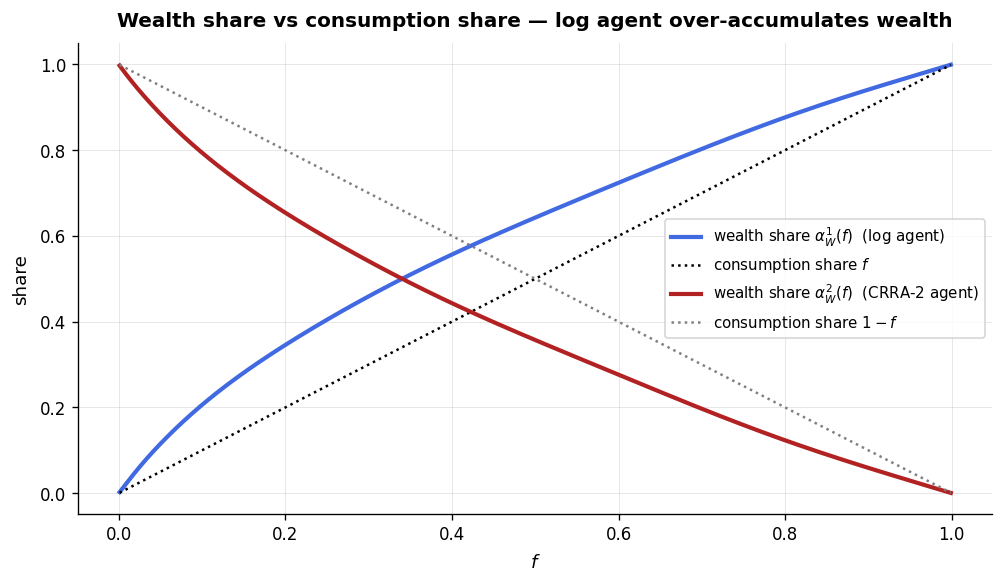

In [13]:
# =============================================================================
# Cell 11 — Wealth-share vs. consumption-share gap.
#
# α^i_W(f) = φ^i(f) · f^i / (φ^e + φ^d)              (wealth share)
#     where f^1 = f, f^2 = 1 − f are the consumption shares.
#
# In a heterogeneous economy with γ^1 < γ^2, the less risk-averse agent
# (here γ^1) holds a larger wealth share than its consumption share at
# every interior f, because they save more per unit of consumption.
# This cell plots both wealth-share curves alongside their consumption-share
# references (f and 1 − f) to visualise the gap.
#
# Uses the f_grid, phi1_f, phi2_f, phi_e_f, phi_d_f set in Cell 9.
# =============================================================================
import matplotlib.pyplot as plt


# ---- Wealth shares ------------------------------------------------------
W_tot    = phi_e_f + phi_d_f                                                 # total wealth per unit Y
alpha_W1 = phi1_f * f_grid       / W_tot                                     # wealth share, agent 1
alpha_W2 = phi2_f * (1 - f_grid) / W_tot                                     # wealth share, agent 2


# ---- Plot ---------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8.5, 5))
ax.plot(f_grid, alpha_W1, lw=2.5, color='royalblue',
        label=r'wealth share $\alpha^1_W(f)$  (log agent)')
ax.plot(f_grid, f_grid, lw=1.5, color='black', ls=':',
        label=r'consumption share $f$')
ax.plot(f_grid, alpha_W2, lw=2.5, color='firebrick',
        label=r'wealth share $\alpha^2_W(f)$  (CRRA-2 agent)')
ax.plot(f_grid, 1 - f_grid, lw=1.5, color='gray', ls=':',
        label=r'consumption share $1-f$')
ax.set_xlabel('$f$');  ax.set_ylabel('share')
ax.set_title('Wealth share vs consumption share — log agent over-accumulates wealth',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3);  ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Results_hetero/wealth_share_gap.png', dpi=200, bbox_inches='tight')
plt.show()